# Pokémon GO Reviews — Exploratory Data Analysis

Comprehensive side-by-side EDA comparing two datasets scraped from the Google Play Store:

| Dataset | File | Ordering |
|---|---|---|
| **Newest** | `pokemon_go_reviews8.json` | Sorted by most recent |
| **Most Relevant** | `pokemon_go_reviews_most_relevant.json` | Sorted by relevance / helpfulness |

Sections covered:
1. Data loading & cleaning
2. Summary statistics
3. Star rating distributions
4. Helpful-count distributions
5. Review-length analysis
6. Temporal distribution
7. Scatter plots
8. Correlation analysis
9. Normality tests (Shapiro-Wilk, D'Agostino K², KS)
10. VIF (variance inflation factor)
11. Statistical significance tests between datasets


In [3]:
%pip install -q pandas numpy matplotlib seaborn scipy statsmodels


Note: you may need to restart the kernel to use updated packages.


In [4]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import (
    shapiro, normaltest, kstest, ks_2samp,
    mannwhitneyu, chi2_contingency, spearmanr, pearsonr
)
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

PALETTE = {"Newest": "#4C72B0", "Most Relevant": "#DD8452"}
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)

print("All imports OK")


All imports OK


In [5]:
DATA_DIR = Path(".")

def load_reviews(filename: str, label: str) -> pd.DataFrame:
    with open(DATA_DIR / filename, encoding="utf-8") as f:
        records = json.load(f)
    df = pd.DataFrame(records)
    df["dataset"] = label

    # Parse date
    df["date"] = pd.to_datetime(df["date"], format="%B %d, %Y", errors="coerce")

    # Derived features
    df["review_length"]   = df["review_text"].str.len()
    df["word_count"]      = df["review_text"].str.split().str.len()
    df["log_helpful"]     = np.log1p(df["helpful_count"])
    df["log_review_len"]  = np.log1p(df["review_length"])

    return df

df_new = load_reviews("pokemon_go_reviews8.json",            "Newest")
df_rel = load_reviews("pokemon_go_reviews_most_relevant.json", "Most Relevant")
df_all = pd.concat([df_new, df_rel], ignore_index=True)

print(f"Newest:       {len(df_new):>5} reviews")
print(f"Most Relevant:{len(df_rel):>5} reviews")
print(f"Combined:     {len(df_all):>5} reviews")
df_new.head(3)


Newest:       20100 reviews
Most Relevant:18280 reviews
Combined:     38380 reviews


,review_id,nickname,stars,date,review_text,helpful_count,dataset,review_length,word_count,log_helpful,log_review_len
0,16e074f3-2ab3-4669-9c83-59f8123abc72,Miles Gabuzda,5,2026-04-16,great game,0,Newest,10,2,0.0000,2.3979
1,8b9b2783-d7af-4c38-a40c-7c1fcfb56fa6,Colby Milisi,4,2026-04-16,fun but gets boring sorry,0,Newest,25,5,0.0000,3.2581
2,60588527-9541-4e16-900a-308aa691b07d,Amanda Childers,5,2026-04-16,can't get gigantic max pokemon and it kicked m...,0,Newest,72,16,0.0000,4.2905


## 1 · Data Overview & Basic Info


In [4]:
print("=" * 60)
print("NEWEST — dtypes & nulls")
print("=" * 60)
info_new = pd.DataFrame({
    "dtype":    df_new.dtypes,
    "non_null": df_new.notna().sum(),
    "null":     df_new.isna().sum(),
})
display(info_new)

print("\n" + "=" * 60)
print("MOST RELEVANT — dtypes & nulls")
print("=" * 60)
info_rel = pd.DataFrame({
    "dtype":    df_rel.dtypes,
    "non_null": df_rel.notna().sum(),
    "null":     df_rel.isna().sum(),
})
display(info_rel)


NEWEST — dtypes & nulls


,dtype,non_null,null
review_id,str,20100,0
nickname,str,20100,0
stars,int64,20100,0
date,datetime64[us],20100,0
review_text,str,20100,0
helpful_count,int64,20100,0
dataset,str,20100,0
review_length,int64,20100,0
word_count,int64,20100,0
log_helpful,float64,20100,0



MOST RELEVANT — dtypes & nulls


,dtype,non_null,null
review_id,str,18280,0
nickname,str,18280,0
stars,int64,18280,0
date,datetime64[us],18280,0
review_text,str,18280,0
helpful_count,int64,18280,0
dataset,str,18280,0
review_length,int64,18280,0
word_count,int64,18280,0
log_helpful,float64,18280,0


## 2 · Summary Statistics (Side-by-Side)


In [5]:
NUM_COLS = ["stars", "helpful_count", "review_length", "word_count"]

stats_new = df_new[NUM_COLS].describe(percentiles=[.25, .5, .75, .90, .95]).T
stats_rel = df_rel[NUM_COLS].describe(percentiles=[.25, .5, .75, .90, .95]).T

# Add skewness & kurtosis
for df_, stats_ in [(df_new, stats_new), (df_rel, stats_rel)]:
    stats_["skewness"] = df_[NUM_COLS].skew()
    stats_["kurtosis"] = df_[NUM_COLS].kurt()

combined = pd.concat(
    [stats_new, stats_rel],
    axis=1,
    keys=["Newest", "Most Relevant"]
)
display(combined.round(3))


Newest                                                    \
                   count     mean      std    min     25%     50%      75%   
stars         20100.0000   2.7440   1.7360 1.0000  1.0000  2.0000   5.0000   
helpful_count 20100.0000   6.7900  91.4940 0.0000  0.0000  0.0000   2.0000   
review_length 20100.0000 143.0850 138.6260 1.0000 35.0000 95.0000 207.0000   
word_count    20100.0000  27.1480  25.9870 1.0000  7.0000 18.0000  39.0000   

                                                             Most Relevant  \
                   90%      95%       max skewness  kurtosis         count   
stars           5.0000   5.0000    5.0000   0.2490   -1.6890    18280.0000   
helpful_count   5.0000  10.0000 9006.0000  58.1420 4974.5660    18280.0000   
review_length 376.0000 478.0000  737.0000   1.2040    0.4800    18280.0000   
word_count     70.0000  87.0000  133.0000   1.2010    0.5190    18280.0000   

                                                                             \
                  mean      std     min      25%      50%      75%      90%   
stars           2.5430   1.4810  1.0000   1.0000   2.0000   4.0000   5.0000   
helpful_count  25.9520 160.1950  0.0000   0.0000   2.0000   8.0000  31.0000   
review_length 367.4070 123.8360 26.0000 289.0000 367.0000 471.0000 497.0000   
word_count     68.9630  23.3570  4.0000  54.0000  69.0000  86.0000  94.0000   

                                                      
                   95%        max skewness  kurtosis  
stars           5.0000     5.0000   0.3790   -1.3140  
helpful_count  86.0500 10891.0000  31.9520 1765.2660  
review_length 499.0000  2717.0000   2.0800   32.8740  
word_count     98.0000   477.0000   1.8410   27.3050

## 3 · Star Rating Distributions


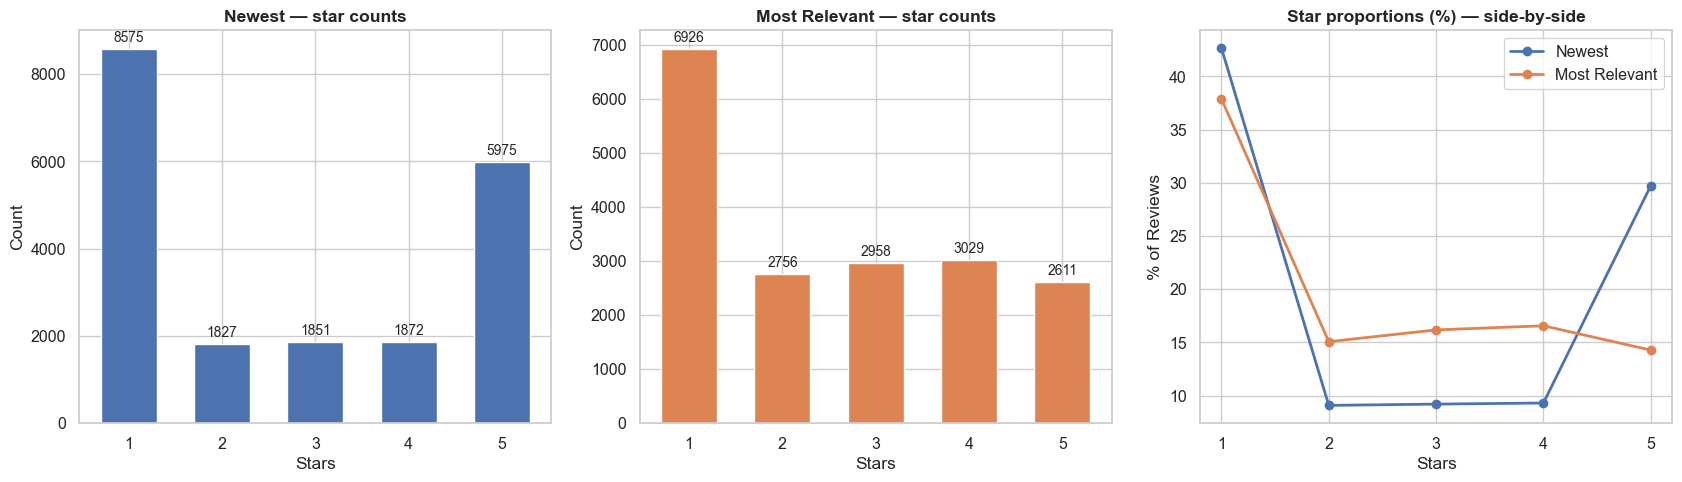

,Newest %,Most Relevant %
stars,,
1,42.6600,37.8900
2,9.0900,15.0800
3,9.2100,16.1800
4,9.3100,16.5700
5,29.7300,14.2800


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# --- Absolute counts ---
for ax, (df_, label) in zip(axes[:2], [(df_new, "Newest"), (df_rel, "Most Relevant")]):
    counts = df_["stars"].value_counts().sort_index()
    bars = ax.bar(counts.index, counts.values, color=PALETTE[label], edgecolor="white", width=0.6)
    ax.bar_label(bars, padding=3, fontsize=10)
    ax.set_title(f"{label} — star counts", fontweight="bold")
    ax.set_xlabel("Stars"); ax.set_ylabel("Count")
    ax.set_xticks([1, 2, 3, 4, 5])

# --- Proportions overlaid ---
for label, df_, color in [("Newest", df_new, PALETTE["Newest"]),
                           ("Most Relevant", df_rel, PALETTE["Most Relevant"])]:
    prop = df_["stars"].value_counts(normalize=True).sort_index()
    axes[2].plot(prop.index, prop.values * 100, marker="o", color=color, label=label, linewidth=2)
axes[2].set_title("Star proportions (%) — side-by-side", fontweight="bold")
axes[2].set_xlabel("Stars"); axes[2].set_ylabel("% of Reviews")
axes[2].set_xticks([1, 2, 3, 4, 5])
axes[2].legend()

plt.tight_layout()
plt.savefig("star_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

# Numeric proportion table
prop_new = df_new["stars"].value_counts(normalize=True).sort_index().rename("Newest %")
prop_rel = df_rel["stars"].value_counts(normalize=True).sort_index().rename("Most Relevant %")
display((pd.concat([prop_new, prop_rel], axis=1) * 100).round(2))


## 4 · Helpful-Count Distributions


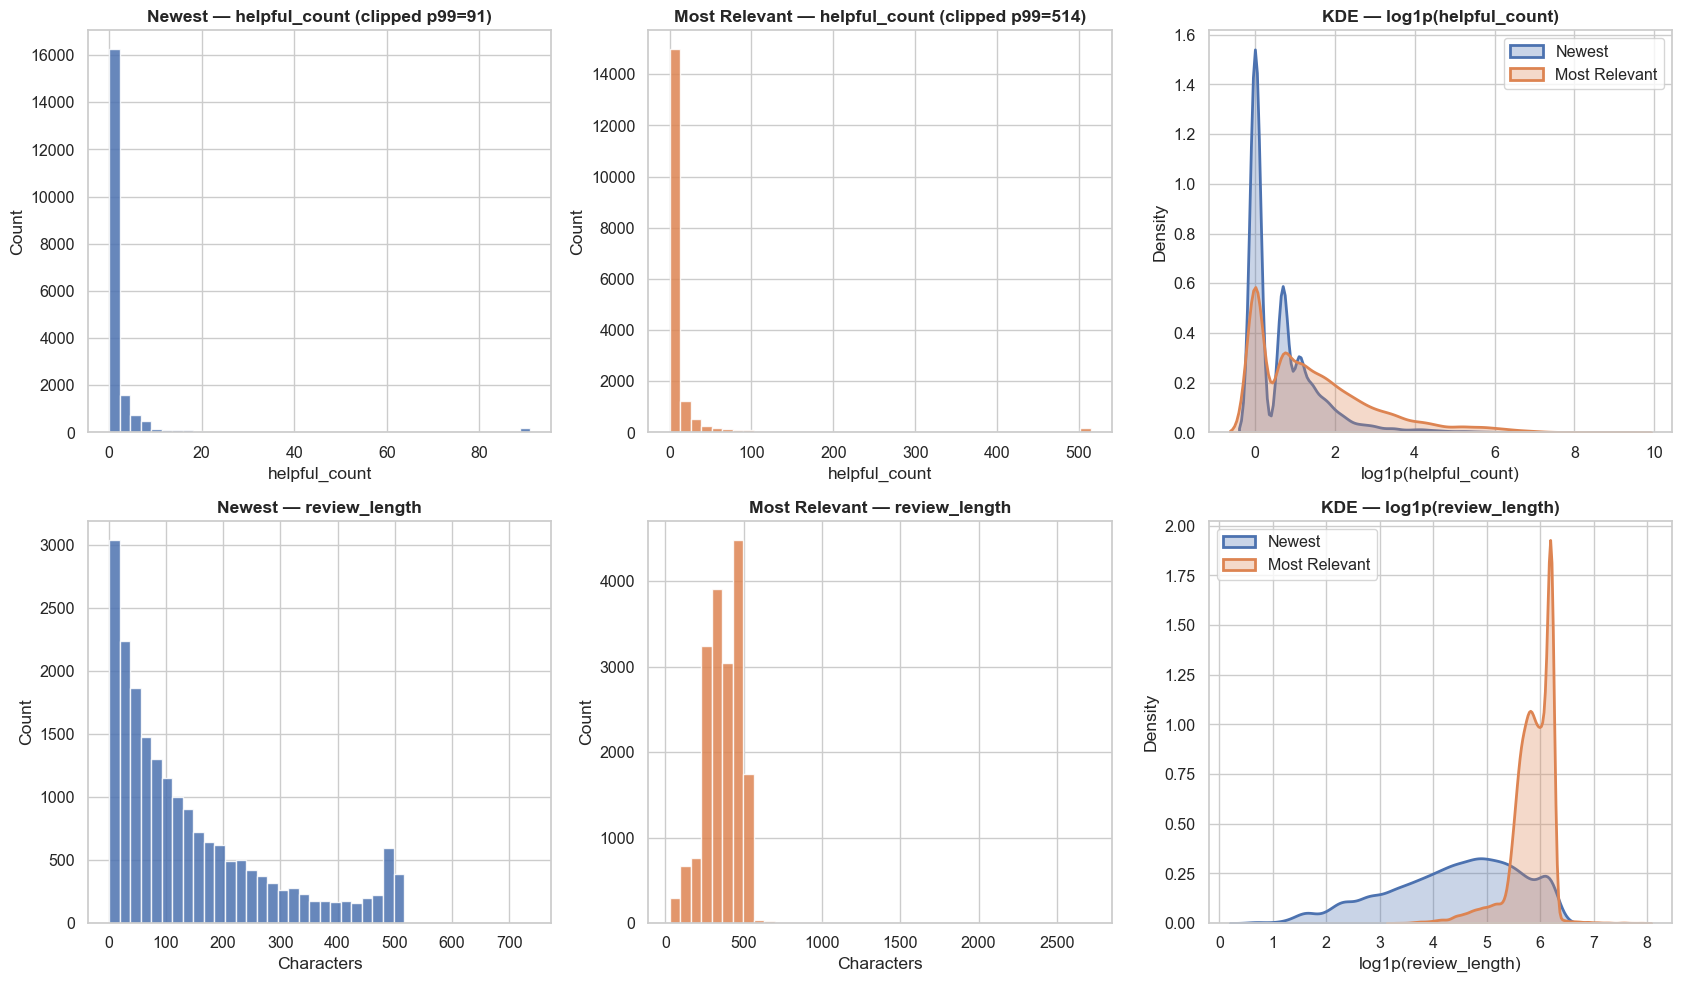

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))

datasets = [("Newest", df_new), ("Most Relevant", df_rel)]

for col, (ax_hist, ax_box, ax_log) in zip(
    ["helpful_count", "helpful_count"],
    [(axes[0, 0], axes[0, 1], axes[0, 2]),
     (axes[1, 0], axes[1, 1], axes[1, 2])]
):
    pass  # replaced below

# Row 0 — raw helpful_count
for i, (label, df_) in enumerate(datasets):
    color = PALETTE[label]
    # Histogram (clipped at 99th pct for visibility)
    clip = df_["helpful_count"].quantile(0.99)
    clipped = df_["helpful_count"].clip(upper=clip)
    axes[0, i].hist(clipped, bins=40, color=color, edgecolor="white", alpha=0.85)
    axes[0, i].set_title(f"{label} — helpful_count (clipped p99={clip:.0f})", fontweight="bold")
    axes[0, i].set_xlabel("helpful_count"); axes[0, i].set_ylabel("Count")

# Overlaid KDE of log1p(helpful_count)
for label, df_ in datasets:
    sns.kdeplot(df_["log_helpful"], ax=axes[0, 2], label=label, color=PALETTE[label], linewidth=2, fill=True, alpha=0.3)
axes[0, 2].set_title("KDE — log1p(helpful_count)", fontweight="bold")
axes[0, 2].set_xlabel("log1p(helpful_count)"); axes[0, 2].legend()

# Row 1 — review_length
for i, (label, df_) in enumerate(datasets):
    color = PALETTE[label]
    axes[1, i].hist(df_["review_length"], bins=40, color=color, edgecolor="white", alpha=0.85)
    axes[1, i].set_title(f"{label} — review_length", fontweight="bold")
    axes[1, i].set_xlabel("Characters"); axes[1, i].set_ylabel("Count")

# Overlaid KDE of log review_length
for label, df_ in datasets:
    sns.kdeplot(df_["log_review_len"], ax=axes[1, 2], label=label, color=PALETTE[label], linewidth=2, fill=True, alpha=0.3)
axes[1, 2].set_title("KDE — log1p(review_length)", fontweight="bold")
axes[1, 2].set_xlabel("log1p(review_length)"); axes[1, 2].legend()

plt.tight_layout()
plt.savefig("helpful_review_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


## 5 · Temporal Distribution


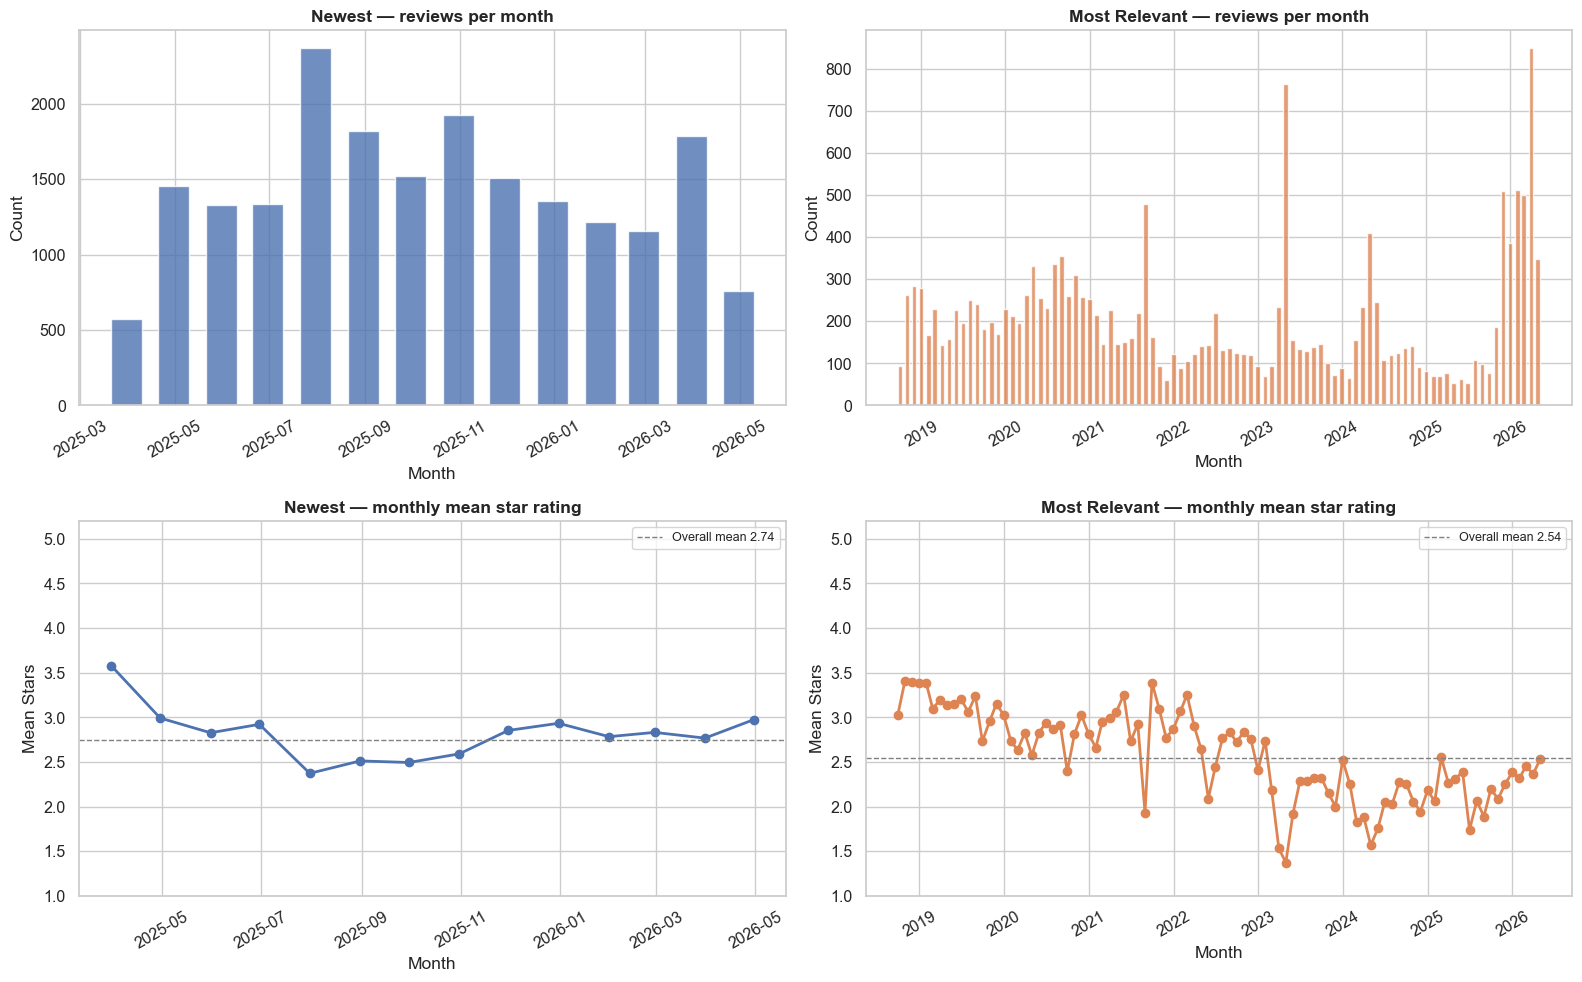

Date range — Newest:        2025-03-25 → 2026-04-16
Date range — Most Relevant: 2018-09-12 → 2026-04-16


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for (label, df_), ax_top, ax_bot in zip(
    datasets,
    [axes[0, 0], axes[0, 1]],
    [axes[1, 0], axes[1, 1]]
):
    color = PALETTE[label]

    # Monthly review count
    monthly = df_.set_index("date").resample("ME")["review_id"].count()
    ax_top.bar(monthly.index, monthly.values, color=color, width=20, alpha=0.8)
    ax_top.set_title(f"{label} — reviews per month", fontweight="bold")
    ax_top.set_xlabel("Month"); ax_top.set_ylabel("Count")
    ax_top.tick_params(axis="x", rotation=30)

    # Monthly mean star rating
    monthly_stars = df_.set_index("date").resample("ME")["stars"].mean()
    ax_bot.plot(monthly_stars.index, monthly_stars.values, color=color, marker="o", linewidth=2)
    ax_bot.axhline(df_["stars"].mean(), color="grey", linestyle="--", linewidth=1, label=f"Overall mean {df_['stars'].mean():.2f}")
    ax_bot.set_title(f"{label} — monthly mean star rating", fontweight="bold")
    ax_bot.set_xlabel("Month"); ax_bot.set_ylabel("Mean Stars")
    ax_bot.set_ylim(1, 5.2)
    ax_bot.legend(fontsize=9)
    ax_bot.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("temporal_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("Date range — Newest:       ", df_new["date"].min().date(), "→", df_new["date"].max().date())
print("Date range — Most Relevant:", df_rel["date"].min().date(), "→", df_rel["date"].max().date())


## 6 · Box-plots & Violin Plots


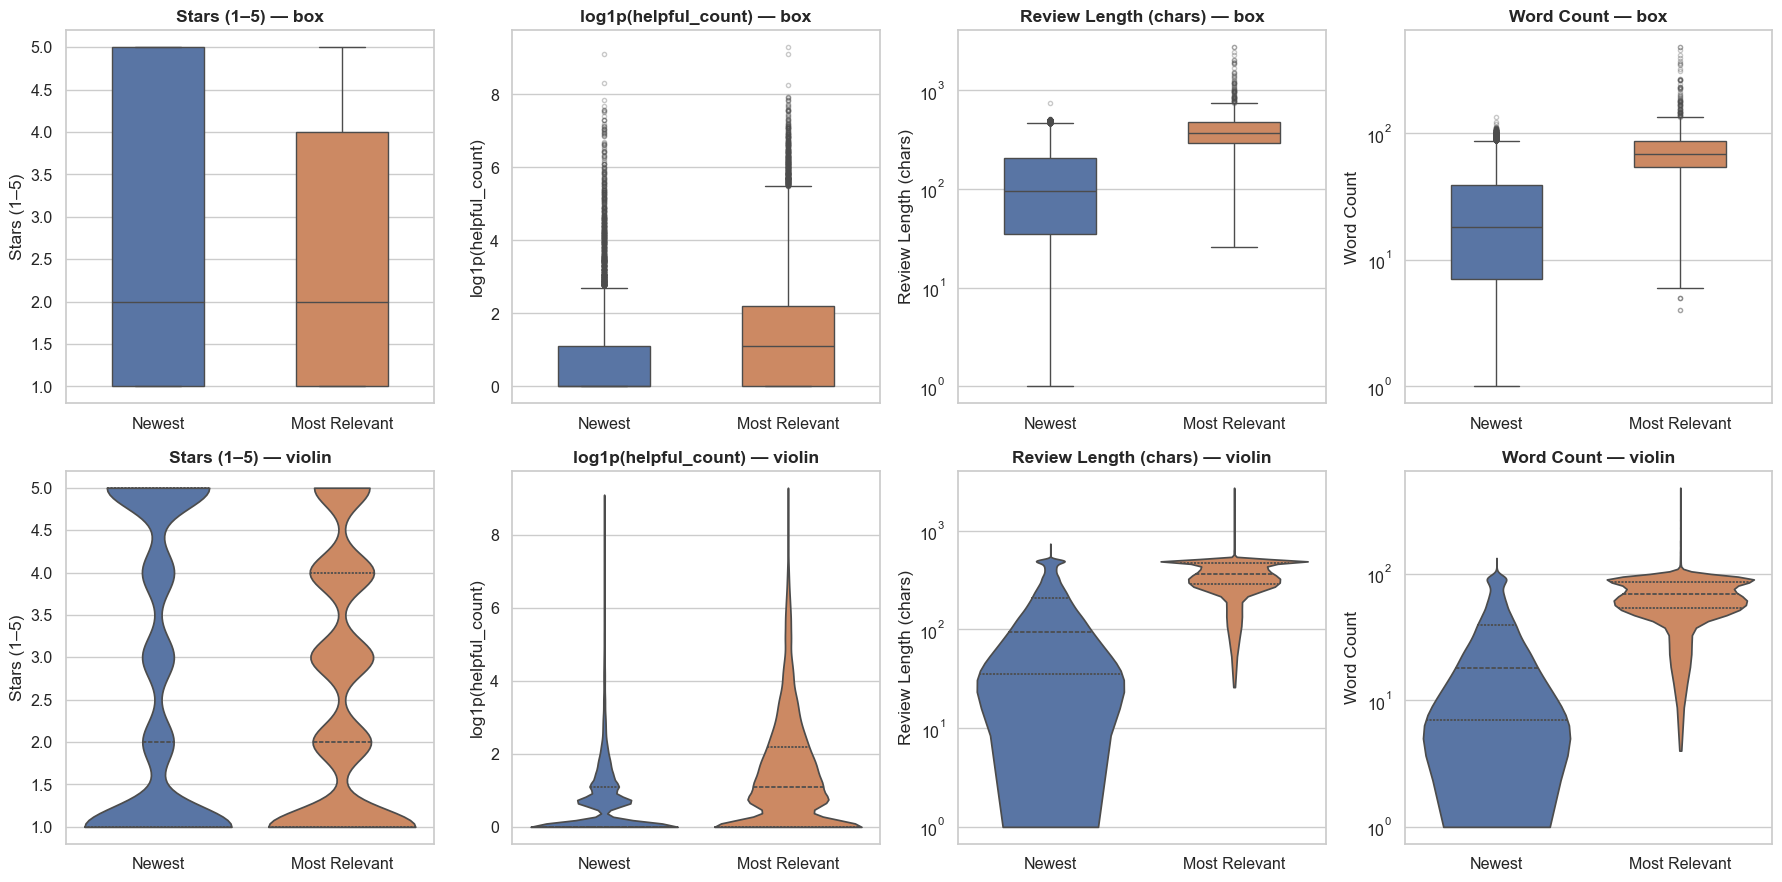

In [9]:
PLOT_VARS = [
    ("stars",          "Stars (1–5)",         False),
    ("log_helpful",    "log1p(helpful_count)", False),
    ("review_length",  "Review Length (chars)", True),
    ("word_count",     "Word Count",            True),
]

fig, axes = plt.subplots(2, len(PLOT_VARS), figsize=(18, 9))

for col_i, (var, label, use_log) in enumerate(PLOT_VARS):
    ax_box = axes[0, col_i]
    ax_vio = axes[1, col_i]

    data_plot = pd.concat([
        df_new[[var]].assign(Dataset="Newest"),
        df_rel[[var]].assign(Dataset="Most Relevant"),
    ])

    sns.boxplot(data=data_plot, x="Dataset", y=var, ax=ax_box,
                palette=PALETTE, width=0.5, flierprops={"marker": ".", "alpha": 0.3})
    ax_box.set_title(f"{label}", fontweight="bold")
    ax_box.set_xlabel(""); ax_box.set_ylabel(label)
    if use_log:
        ax_box.set_yscale("log")

    sns.violinplot(data=data_plot, x="Dataset", y=var, ax=ax_vio,
                   palette=PALETTE, inner="quartile", cut=0)
    ax_vio.set_xlabel(""); ax_vio.set_ylabel(label)
    if use_log:
        ax_vio.set_yscale("log")

axes[0, 0].set_title("Stars (1–5) — Boxplot", fontweight="bold")
axes[1, 0].set_title("Stars (1–5) — Violin", fontweight="bold")
for col_i, (_, label, _) in enumerate(PLOT_VARS):
    axes[0, col_i].set_title(f"{label} — box", fontweight="bold")
    axes[1, col_i].set_title(f"{label} — violin", fontweight="bold")

plt.tight_layout()
plt.savefig("boxplots_violins.png", dpi=150, bbox_inches="tight")
plt.show()


## 7 · Scatter Plots


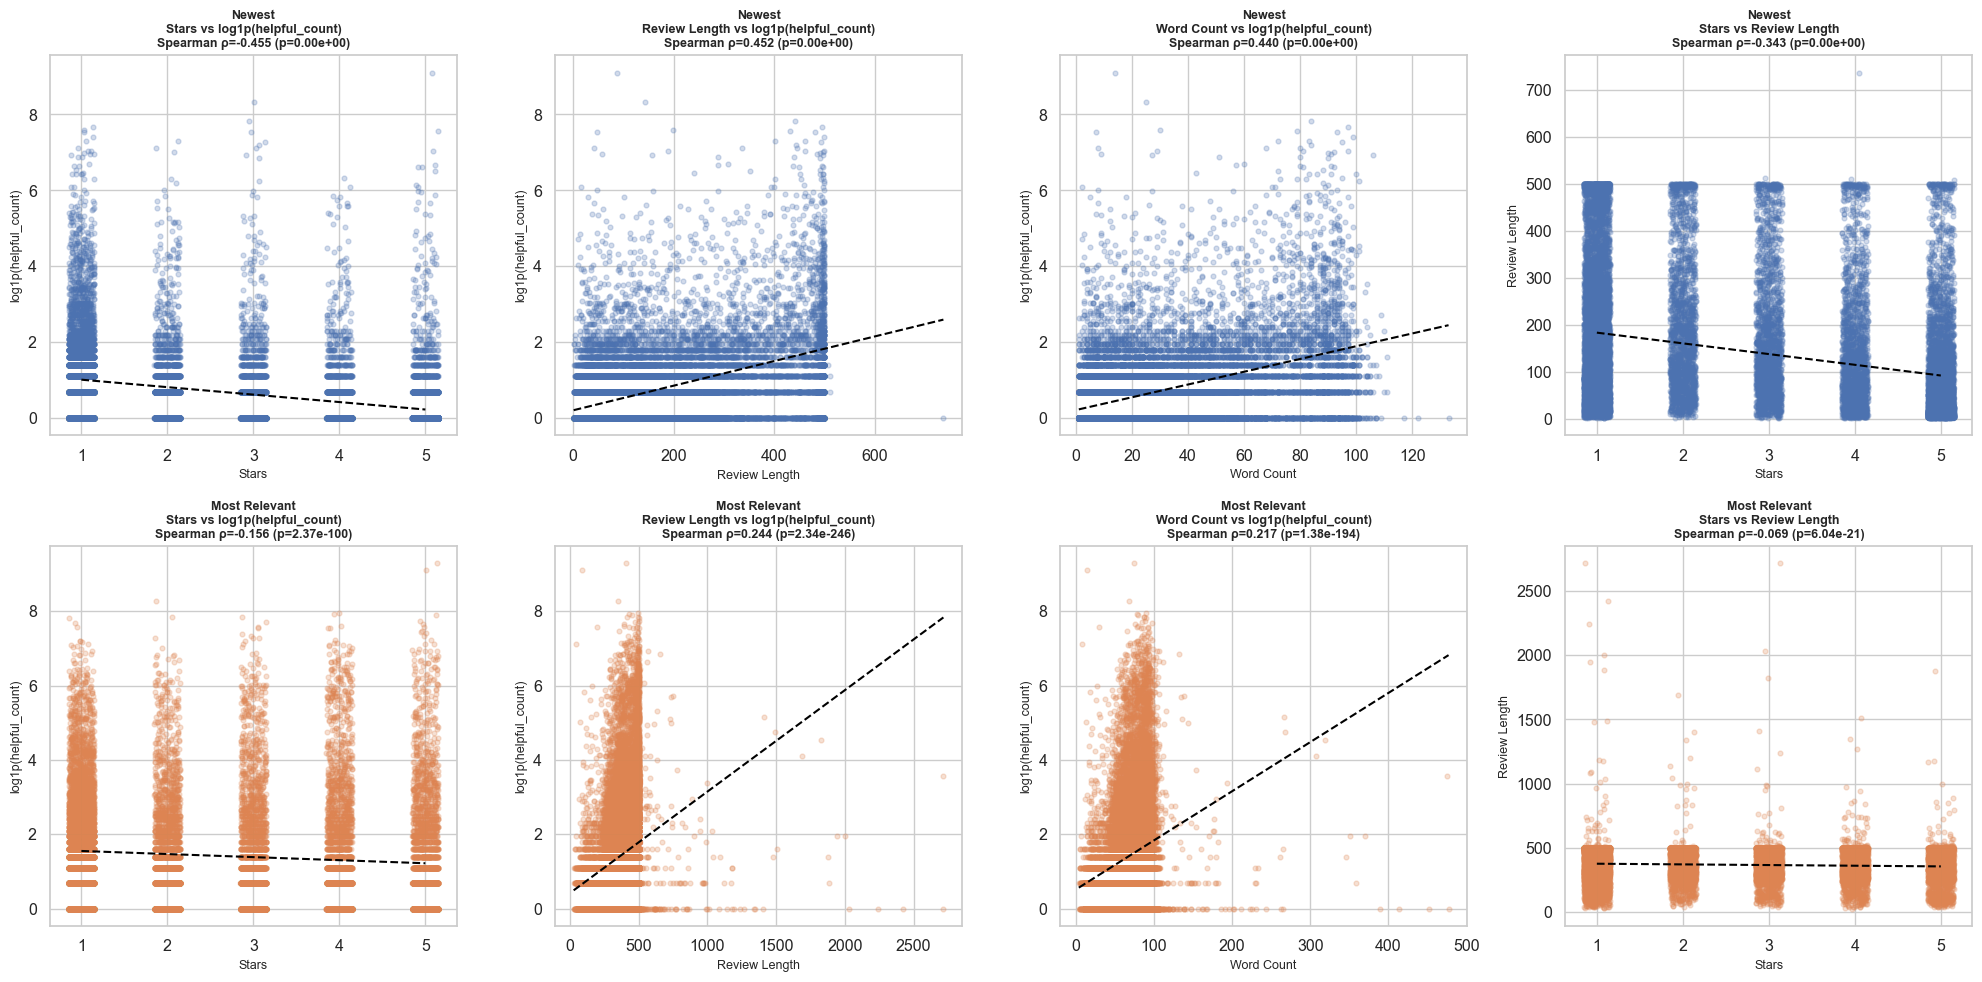

In [10]:
scatter_pairs = [
    ("stars",         "log_helpful",    "Stars",         "log1p(helpful_count)"),
    ("review_length", "log_helpful",    "Review Length", "log1p(helpful_count)"),
    ("word_count",    "log_helpful",    "Word Count",    "log1p(helpful_count)"),
    ("stars",         "review_length",  "Stars",         "Review Length"),
]

fig, axes = plt.subplots(2, len(scatter_pairs), figsize=(20, 10))

for col_i, (x_var, y_var, x_lbl, y_lbl) in enumerate(scatter_pairs):
    for row_i, (label, df_) in enumerate(datasets):
        ax = axes[row_i, col_i]
        color = PALETTE[label]

        # Jitter stars slightly to reduce overplotting
        x = df_[x_var] + (np.random.RandomState(42).uniform(-0.15, 0.15, len(df_)) if x_var == "stars" else 0)
        ax.scatter(x, df_[y_var], alpha=0.25, s=12, color=color)

        # Regression line
        mask = df_[x_var].notna() & df_[y_var].notna()
        m, b = np.polyfit(df_.loc[mask, x_var], df_.loc[mask, y_var], 1)
        xs = np.linspace(df_.loc[mask, x_var].min(), df_.loc[mask, x_var].max(), 100)
        ax.plot(xs, m * xs + b, color="black", linewidth=1.5, linestyle="--")

        rho, pval = spearmanr(df_.loc[mask, x_var], df_.loc[mask, y_var])
        ax.set_title(f"{label}\n{x_lbl} vs {y_lbl}\nSpearman ρ={rho:.3f} (p={pval:.2e})",
                     fontweight="bold", fontsize=9)
        ax.set_xlabel(x_lbl, fontsize=9)
        ax.set_ylabel(y_lbl, fontsize=9)

plt.tight_layout()
plt.savefig("scatter_plots.png", dpi=150, bbox_inches="tight")
plt.show()


## 8 · Correlation Analysis (Pearson & Spearman)


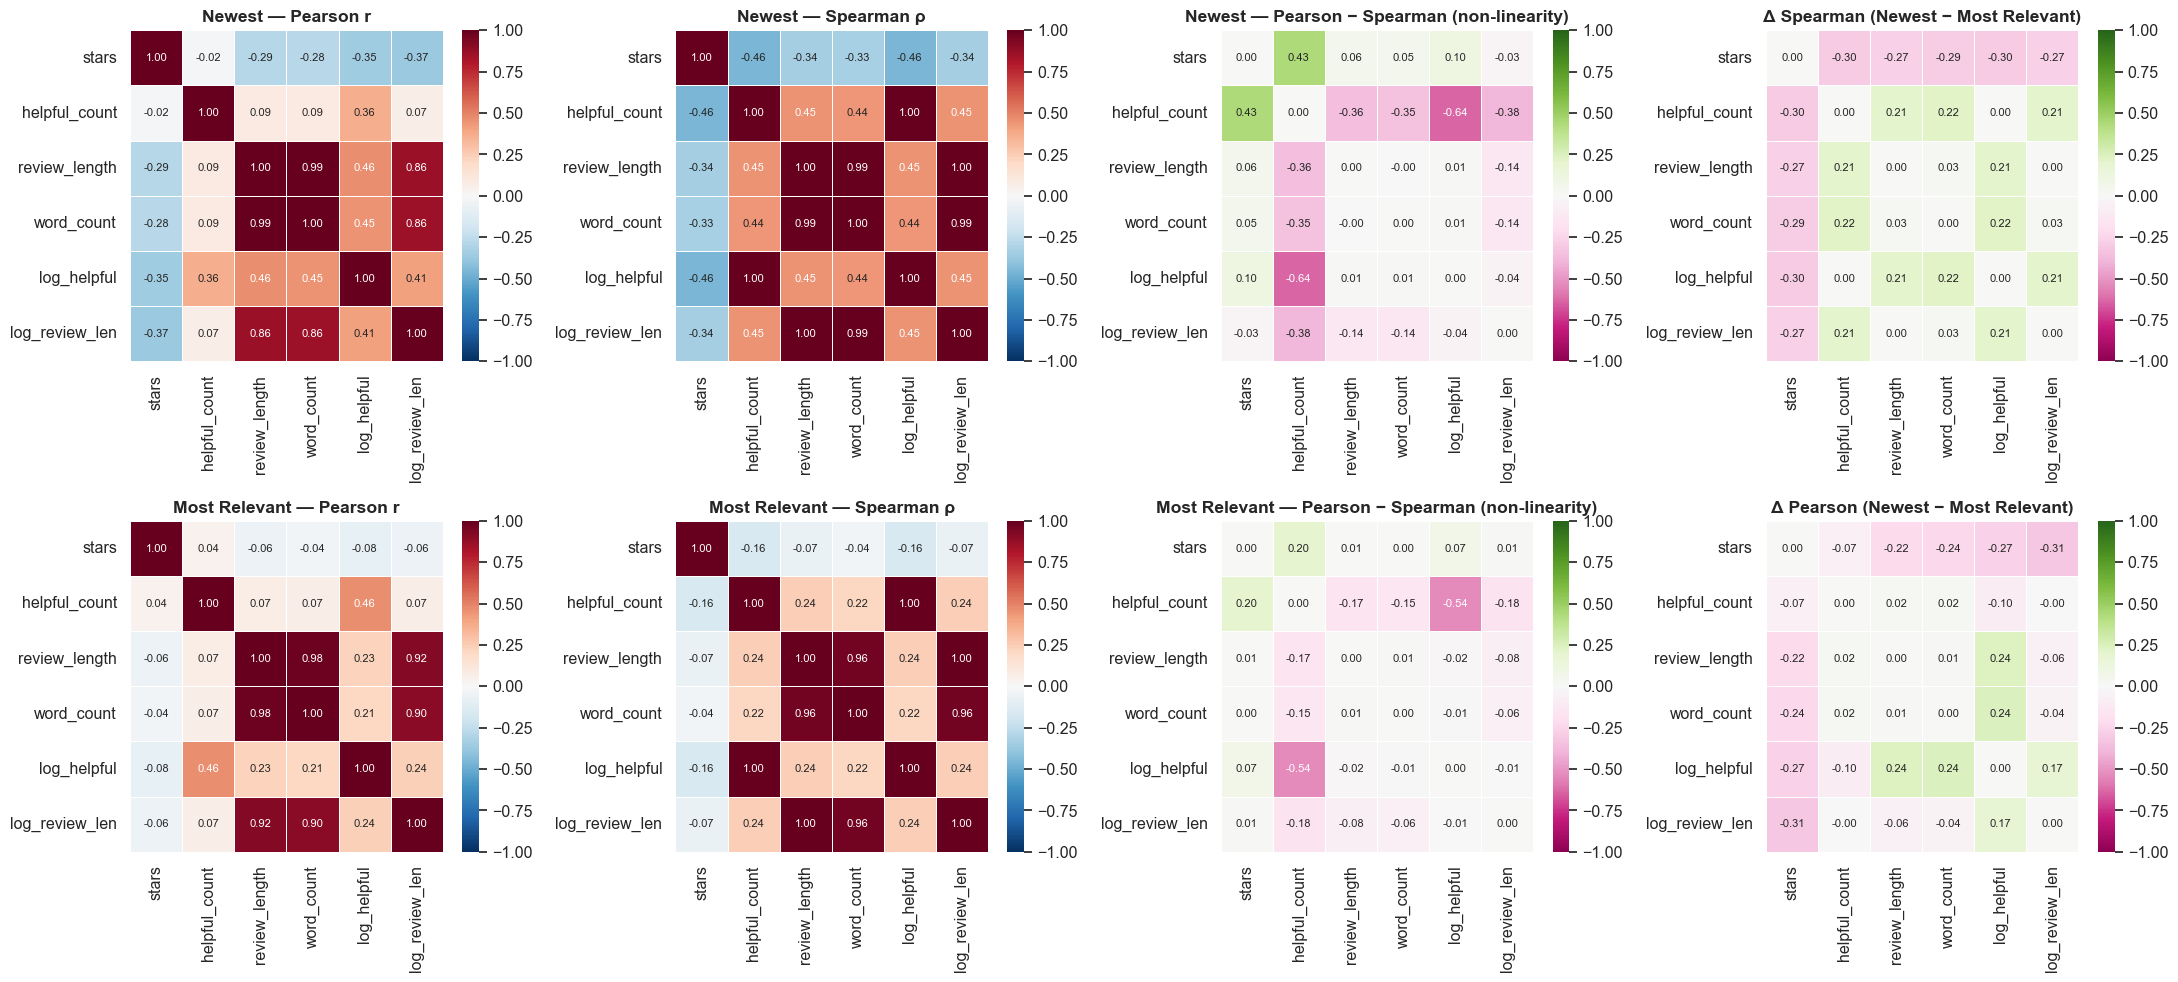

In [11]:
CORR_COLS = ["stars", "helpful_count", "review_length", "word_count", "log_helpful", "log_review_len"]

fig, axes = plt.subplots(2, 4, figsize=(22, 10))

for ds_i, (label, df_) in enumerate(datasets):
    # Pearson
    pearson = df_[CORR_COLS].corr(method="pearson")
    sns.heatmap(pearson, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
                ax=axes[ds_i, 0], vmin=-1, vmax=1, linewidths=0.5,
                annot_kws={"size": 8})
    axes[ds_i, 0].set_title(f"{label} — Pearson r", fontweight="bold")

    # Spearman
    spearman = df_[CORR_COLS].corr(method="spearman")
    sns.heatmap(spearman, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
                ax=axes[ds_i, 1], vmin=-1, vmax=1, linewidths=0.5,
                annot_kws={"size": 8})
    axes[ds_i, 1].set_title(f"{label} — Spearman ρ", fontweight="bold")

    # Difference Pearson - Spearman (highlights non-linearity)
    diff = pearson - spearman
    sns.heatmap(diff, annot=True, fmt=".2f", cmap="PiYG", center=0,
                ax=axes[ds_i, 2], vmin=-1, vmax=1, linewidths=0.5,
                annot_kws={"size": 8})
    axes[ds_i, 2].set_title(f"{label} — Pearson − Spearman (non-linearity)", fontweight="bold")

# Difference between datasets — Spearman
diff_ds = (df_new[CORR_COLS].corr(method="spearman") -
           df_rel[CORR_COLS].corr(method="spearman"))
sns.heatmap(diff_ds, annot=True, fmt=".2f", cmap="PiYG", center=0,
            ax=axes[0, 3], vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={"size": 8})
axes[0, 3].set_title("Δ Spearman (Newest − Most Relevant)", fontweight="bold")

diff_ds_p = (df_new[CORR_COLS].corr(method="pearson") -
             df_rel[CORR_COLS].corr(method="pearson"))
sns.heatmap(diff_ds_p, annot=True, fmt=".2f", cmap="PiYG", center=0,
            ax=axes[1, 3], vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={"size": 8})
axes[1, 3].set_title("Δ Pearson (Newest − Most Relevant)", fontweight="bold")

plt.tight_layout()
plt.savefig("correlation_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()


## 9 · Normality Tests

Three complementary tests per variable per dataset:
- **Shapiro-Wilk** (most powerful for small samples; may be conservative for N > 5000)
- **D'Agostino K²** (`normaltest`) — combines skewness + kurtosis
- **Kolmogorov-Smirnov** (vs. a fitted normal) — non-parametric, no power issue with large N


In [12]:
NORM_COLS = ["stars", "helpful_count", "review_length", "word_count", "log_helpful", "log_review_len"]

rows = []
for label, df_ in datasets:
    for col in NORM_COLS:
        x = df_[col].dropna().values
        # Shapiro-Wilk (subsample to 5000 max for speed/stability)
        x_sw = x if len(x) <= 5000 else np.random.RandomState(42).choice(x, 5000, replace=False)
        sw_stat, sw_p  = shapiro(x_sw)
        da_stat, da_p  = normaltest(x)
        # KS vs fitted normal
        ks_stat, ks_p  = kstest(x, "norm", args=(x.mean(), x.std(ddof=1)))

        rows.append({
            "Dataset":     label,
            "Variable":    col,
            "N":           len(x),
            "Skewness":    pd.Series(x).skew(),
            "Kurtosis":    pd.Series(x).kurt(),
            "SW stat":     sw_stat, "SW p-value":  sw_p,  "SW normal?": "✓" if sw_p > 0.05 else "✗",
            "DA stat":     da_stat, "DA p-value":  da_p,  "DA normal?": "✓" if da_p > 0.05 else "✗",
            "KS stat":     ks_stat, "KS p-value":  ks_p,  "KS normal?": "✓" if ks_p > 0.05 else "✗",
        })

norm_df = pd.DataFrame(rows)
display(norm_df.set_index(["Dataset", "Variable"]).round(4))


N  Skewness  Kurtosis  SW stat  SW p-value  \
Dataset       Variable                                                         
Newest        stars           20100    0.2491   -1.6889   0.7682      0.0000   
              helpful_count   20100   58.1418 4974.5661   0.0655      0.0000   
              review_length   20100    1.2039    0.4804   0.8452      0.0000   
              word_count      20100    1.2006    0.5186   0.8523      0.0000   
              log_helpful     20100    2.3692    8.2430   0.7070      0.0000   
              log_review_len  20100   -0.4974   -0.4544   0.9649      0.0000   
Most Relevant stars           18280    0.3789   -1.3135   0.8376      0.0000   
              helpful_count   18280   31.9516 1765.2656   0.2003      0.0000   
              review_length   18280    2.0804   32.8744   0.8215      0.0000   
              word_count      18280    1.8405   27.3050   0.8566      0.0000   
              log_helpful     18280    1.3087    1.6504   0.8576      0.0000   
              log_review_len  18280   -1.6699    4.9745   0.8417      0.0000   

                             SW normal?     DA stat  DA p-value DA normal?  \
Dataset       Variable                                                       
Newest        stars                   ✗  88123.6013      0.0000          ✗   
              helpful_count           ✗  66779.8506      0.0000          ✗   
              review_length           ✗   3243.4716      0.0000          ✗   
              word_count              ✗   3248.2211      0.0000          ✗   
              log_helpful             ✗  10259.5196      0.0000          ✗   
              log_review_len          ✗   1040.4353      0.0000          ✗   
Most Relevant stars                   ✗ 106830.4701      0.0000          ✗   
              helpful_count           ✗  48794.1899      0.0000          ✗   
              review_length           ✗  10982.4904      0.0000          ✗   
              word_count              ✗   9913.3255      0.0000          ✗   
              log_helpful             ✗   3857.6550      0.0000          ✗   
              log_review_len          ✗   6356.1149      0.0000          ✗   

                              KS stat  KS p-value KS normal?  
Dataset       Variable                                        
Newest        stars            0.2690      0.0000          ✗  
              helpful_count    0.4704      0.0000          ✗  
              review_length    0.1528      0.0000          ✗  
              word_count       0.1572      0.0000          ✗  
              log_helpful      0.2705      0.0000          ✗  
              log_review_len   0.0655      0.0000          ✗  
Most Relevant stars            0.2301      0.0000          ✗  
              helpful_count    0.4357      0.0000          ✗  
              review_length    0.1277      0.0000          ✗  
              word_count       0.0667      0.0000          ✗  
              log_helpful      0.1698      0.0000          ✗  
              log_review_len   0.1594      0.0000          ✗

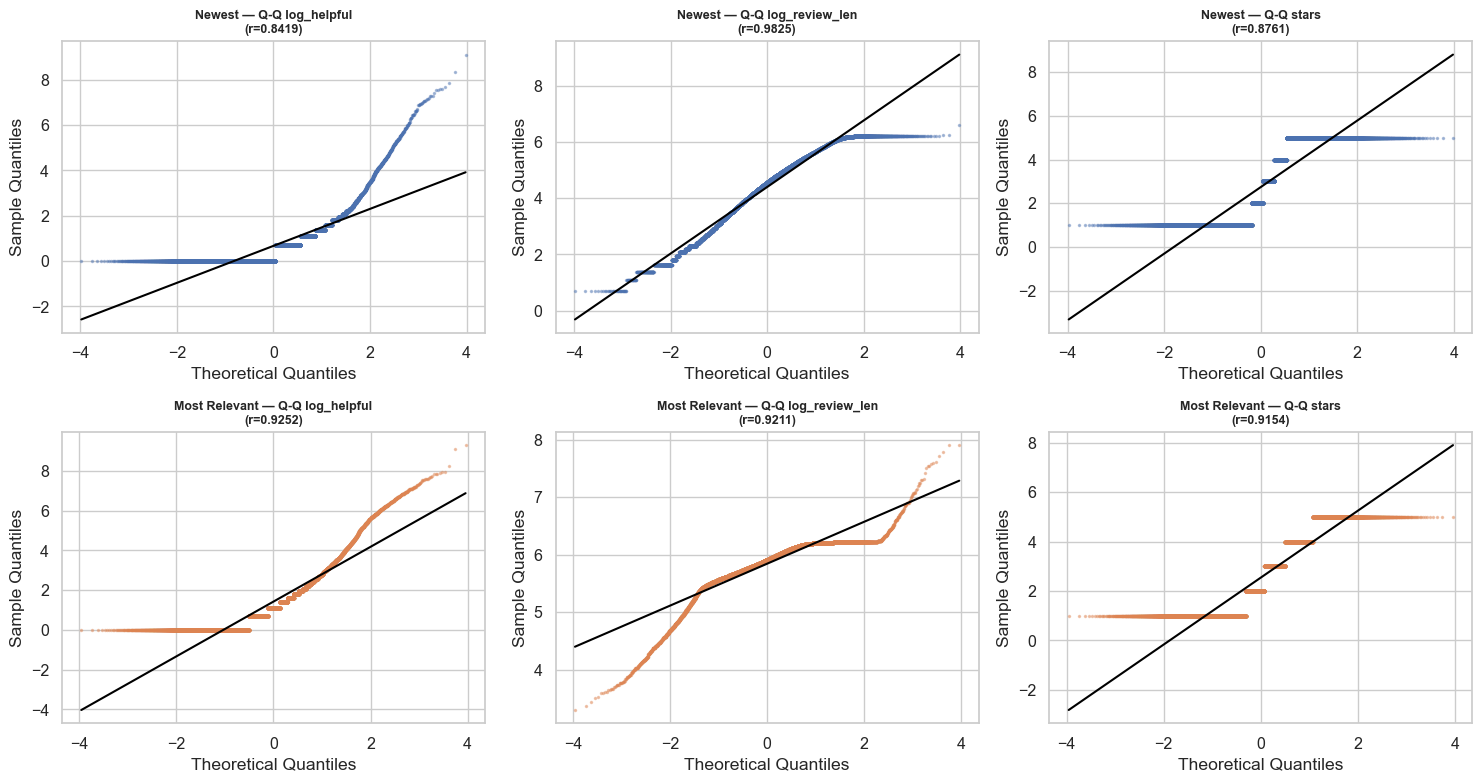

In [13]:
# Q-Q plots for log-transformed variables (closest to normal)
QQ_VARS = ["log_helpful", "log_review_len", "stars"]
fig, axes = plt.subplots(len(datasets), len(QQ_VARS), figsize=(15, 8))

for ds_i, (label, df_) in enumerate(datasets):
    color = PALETTE[label]
    for col_i, var in enumerate(QQ_VARS):
        ax = axes[ds_i, col_i]
        x = df_[var].dropna().values
        (osm, osr), (slope, intercept, r) = stats.probplot(x, dist="norm")
        ax.plot(osm, osr, ".", alpha=0.4, markersize=3, color=color)
        ax.plot(osm, slope * np.array(osm) + intercept, color="black", linewidth=1.5)
        ax.set_title(f"{label} — Q-Q {var}\n(r={r:.4f})", fontweight="bold", fontsize=9)
        ax.set_xlabel("Theoretical Quantiles"); ax.set_ylabel("Sample Quantiles")

plt.tight_layout()
plt.savefig("qq_plots.png", dpi=150, bbox_inches="tight")
plt.show()


## 10 · Variance Inflation Factor (VIF)

VIF measures multicollinearity among the numeric predictors.  
Rule of thumb: VIF > 5 signals moderate multicollinearity; VIF > 10 is severe.  
We treat `stars`, `review_length`, `word_count`, `log_helpful` as predictors.


,VIF (Newest),VIF (Most Relevant),Δ VIF
Feature,,,
review_length,73.8450,25.7270,48.1180
word_count,72.5650,25.4580,47.1080
log_helpful,1.3740,1.0640,0.3100
stars,1.1700,1.0250,0.1450


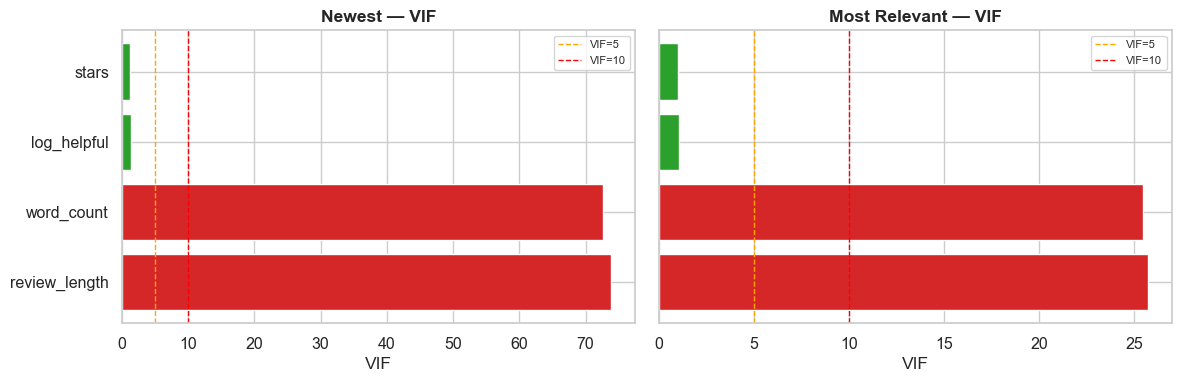

In [14]:
VIF_COLS = ["stars", "review_length", "word_count", "log_helpful"]

def compute_vif(df_: pd.DataFrame, cols: list) -> pd.DataFrame:
    X = df_[cols].dropna()
    # Add constant for intercept
    from statsmodels.tools.tools import add_constant
    X_const = add_constant(X)
    vif_data = pd.DataFrame({
        "Feature": cols,
        "VIF": [variance_inflation_factor(X_const.values, i + 1) for i in range(len(cols))],
    })
    return vif_data.sort_values("VIF", ascending=False)

vif_new = compute_vif(df_new, VIF_COLS).rename(columns={"VIF": "VIF (Newest)"})
vif_rel = compute_vif(df_rel, VIF_COLS).rename(columns={"VIF": "VIF (Most Relevant)"})

vif_combined = vif_new.merge(vif_rel, on="Feature")
vif_combined["Δ VIF"] = vif_combined["VIF (Newest)"] - vif_combined["VIF (Most Relevant)"]
display(vif_combined.set_index("Feature").round(3))

# Visual
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (label, df_) in zip(axes, datasets):
    vif = compute_vif(df_, VIF_COLS)
    colors = ["#d62728" if v > 10 else "#ff7f0e" if v > 5 else "#2ca02c" for v in vif["VIF"]]
    ax.barh(vif["Feature"], vif["VIF"], color=colors)
    ax.axvline(5, color="orange", linestyle="--", linewidth=1, label="VIF=5")
    ax.axvline(10, color="red", linestyle="--", linewidth=1, label="VIF=10")
    ax.set_title(f"{label} — VIF", fontweight="bold")
    ax.set_xlabel("VIF")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("vif.png", dpi=150, bbox_inches="tight")
plt.show()


## 11 · Statistical Significance Tests Between the Two Datasets

Since normality is unlikely (skewed counts, ordinal ratings), we use **non-parametric** tests:

| Test | Variable | H₀ |
|---|---|---|
| **Chi-square** | `stars` (categorical) | The two datasets have the same star distribution |
| **Mann-Whitney U** | `helpful_count`, `review_length`, `word_count` | The two samples come from the same distribution |
| **Two-sample KS** | All numeric | The two samples have the same CDF |
| **Mood's median** | All numeric | The two samples have the same median |

Significance level α = 0.05.


In [16]:
from scipy.stats import median_test

ALPHA = 0.05
test_rows = []

# --- Chi-square on star counts ---
stars_all = pd.concat([
    df_new["stars"].reset_index(drop=True),
    df_rel["stars"].reset_index(drop=True),
], ignore_index=True)
dataset_labels = pd.Series(
    ["Newest"] * len(df_new) + ["Most Relevant"] * len(df_rel)
)
contingency = pd.crosstab(stars_all, dataset_labels)
chi2, chi_p, dof, _ = chi2_contingency(contingency)
test_rows.append({
    "Variable": "stars", "Test": "Chi-square (distribution)",
    "Statistic": chi2, "p-value": chi_p, "dof/n": dof,
    "Significant (α=0.05)": "YES ✓" if chi_p < ALPHA else "no",
})

# --- Mann-Whitney U + KS + Mood's median ---
TEST_VARS = ["stars", "helpful_count", "review_length", "word_count", "log_helpful"]

for var in TEST_VARS:
    a = df_new[var].dropna().values
    b = df_rel[var].dropna().values

    mw_stat, mw_p = mannwhitneyu(a, b, alternative="two-sided")
    ks_stat, ks_p = ks_2samp(a, b)
    try:
        _, mood_p, _, _ = median_test(a, b)
    except Exception:
        mood_p = float("nan")

    # Effect size: rank-biserial correlation for MWU
    n1, n2 = len(a), len(b)
    rb = 1 - (2 * mw_stat) / (n1 * n2)

    for test_name, stat, pval in [
        ("Mann-Whitney U", mw_stat, mw_p),
        ("Kolmogorov-Smirnov 2-sample", ks_stat, ks_p),
        ("Mood's Median",  None,    mood_p),
    ]:
        test_rows.append({
            "Variable": var,
            "Test": test_name,
            "Statistic": stat if stat is not None else "—",
            "p-value": pval,
            "dof/n": f"n₁={n1}, n₂={n2}",
            "Significant (α=0.05)": "YES ✓" if pval < ALPHA else "no",
            "Effect (rank-biserial r)": f"{rb:.4f}" if test_name == "Mann-Whitney U" else "—",
        })

results_df = pd.DataFrame(test_rows)
display(results_df.set_index(["Variable", "Test"]).round(4))


Statistic  p-value  \
Variable      Test                                                  
stars         Chi-square (distribution)        2128.1941   0.0000   
              Mann-Whitney U              193445505.5000   0.0000   
              Kolmogorov-Smirnov 2-sample         0.1544   0.0000   
              Mood's Median                            —   0.0179   
helpful_count Mann-Whitney U              124851395.0000   0.0000   
              Kolmogorov-Smirnov 2-sample         0.2568   0.0000   
              Mood's Median                            —   0.0000   
review_length Mann-Whitney U               45117333.0000   0.0000   
              Kolmogorov-Smirnov 2-sample         0.6839   0.0000   
              Mood's Median                            —   0.0000   
word_count    Mann-Whitney U               45510943.5000   0.0000   
              Kolmogorov-Smirnov 2-sample         0.6754   0.0000   
              Mood's Median                            —   0.0000   
log_helpful   Mann-Whitney U              124851395.0000   0.0000   
              Kolmogorov-Smirnov 2-sample         0.2568   0.0000   
              Mood's Median                            —   0.0000   

                                                        dof/n  \
Variable      Test                                              
stars         Chi-square (distribution)                     4   
              Mann-Whitney U               n₁=20100, n₂=18280   
              Kolmogorov-Smirnov 2-sample  n₁=20100, n₂=18280   
              Mood's Median                n₁=20100, n₂=18280   
helpful_count Mann-Whitney U               n₁=20100, n₂=18280   
              Kolmogorov-Smirnov 2-sample  n₁=20100, n₂=18280   
              Mood's Median                n₁=20100, n₂=18280   
review_length Mann-Whitney U               n₁=20100, n₂=18280   
              Kolmogorov-Smirnov 2-sample  n₁=20100, n₂=18280   
              Mood's Median                n₁=20100, n₂=18280   
word_count    Mann-Whitney U               n₁=20100, n₂=18280   
              Kolmogorov-Smirnov 2-sample  n₁=20100, n₂=18280   
              Mood's Median                n₁=20100, n₂=18280   
log_helpful   Mann-Whitney U               n₁=20100, n₂=18280   
              Kolmogorov-Smirnov 2-sample  n₁=20100, n₂=18280   
              Mood's Median                n₁=20100, n₂=18280   

                                          Significant (α=0.05)  \
Variable      Test                                               
stars         Chi-square (distribution)                  YES ✓   
              Mann-Whitney U                             YES ✓   
              Kolmogorov-Smirnov 2-sample                YES ✓   
              Mood's Median                              YES ✓   
helpful_count Mann-Whitney U                             YES ✓   
              Kolmogorov-Smirnov 2-sample                YES ✓   
              Mood's Median                              YES ✓   
review_length Mann-Whitney U                             YES ✓   
              Kolmogorov-Smirnov 2-sample                YES ✓   
              Mood's Median                              YES ✓   
word_count    Mann-Whitney U                             YES ✓   
              Kolmogorov-Smirnov 2-sample                YES ✓   
              Mood's Median                              YES ✓   
log_helpful   Mann-Whitney U                             YES ✓   
              Kolmogorov-Smirnov 2-sample                YES ✓   
              Mood's Median                              YES ✓   

                                          Effect (rank-biserial r)  
Variable      Test                                                  
stars         Chi-square (distribution)                        NaN  
              Mann-Whitney U                               -0.0530  
              Kolmogorov-Smirnov 2-sample                        —  
              Mood's Median                                      —  
helpful_count Mann-Whitney U  

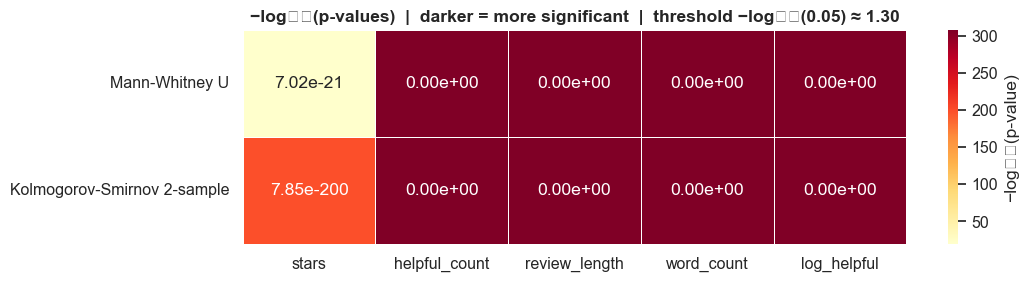

                             stars  helpful_count  review_length  word_count  log_helpful
Mann-Whitney U              0.0000         0.0000         0.0000      0.0000       0.0000
Kolmogorov-Smirnov 2-sample 0.0000         0.0000         0.0000      0.0000       0.0000


In [19]:
# Visual summary of p-values
sig_vars = ["stars", "helpful_count", "review_length", "word_count", "log_helpful"]
test_names_short = ["Mann-Whitney U", "Kolmogorov-Smirnov 2-sample"]

pval_matrix = pd.DataFrame(index=test_names_short, columns=sig_vars, dtype=float)
for var in sig_vars:
    a = df_new[var].dropna().values
    b = df_rel[var].dropna().values
    _, mw_p = mannwhitneyu(a, b, alternative="two-sided")
    _, ks_p = ks_2samp(a, b)
    pval_matrix.loc["Mann-Whitney U", var] = mw_p
    pval_matrix.loc["Kolmogorov-Smirnov 2-sample", var] = ks_p

pval_float = pval_matrix.astype(float)
# Clamp to machine epsilon to avoid -inf in log
pval_clamped = pval_float.clip(lower=np.finfo(float).tiny)
pval_log = -np.log10(pval_clamped)

# Annotation: scientific notation of actual p-values
annot_labels = pval_float.map(lambda x: f"{x:.2e}")

fig, ax = plt.subplots(figsize=(11, 3))
sns.heatmap(
    pval_log, annot=annot_labels, fmt="",
    cmap="YlOrRd", ax=ax, linewidths=0.5,
    cbar_kws={"label": "−log₁₀(p-value)"}
)
ax.set_title(
    "−log₁₀(p-values)  |  darker = more significant  |  threshold −log₁₀(0.05) ≈ 1.30",
    fontweight="bold"
)
plt.tight_layout()
plt.savefig("pvalue_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print(pval_float.to_string())


## 12 · Summary & Key Findings


In [20]:
print("=" * 70)
print("KEY FINDINGS SUMMARY")
print("=" * 70)

for label, df_ in datasets:
    stars_mean = df_["stars"].mean()
    stars_med  = df_["stars"].median()
    pct_5star  = (df_["stars"] == 5).mean() * 100
    pct_1star  = (df_["stars"] == 1).mean() * 100
    med_help   = df_["helpful_count"].median()
    max_help   = df_["helpful_count"].max()
    med_len    = df_["review_length"].median()

    print(f"\n{'─'*40}")
    print(f"  {label.upper()}")
    print(f"{'─'*40}")
    print(f"  N reviews:          {len(df_):>8,}")
    print(f"  Mean stars:         {stars_mean:>8.3f}")
    print(f"  Median stars:       {stars_med:>8.1f}")
    print(f"  % 5-star:           {pct_5star:>8.1f}%")
    print(f"  % 1-star:           {pct_1star:>8.1f}%")
    print(f"  Median helpful:     {med_help:>8.0f}")
    print(f"  Max helpful:        {max_help:>8,}")
    print(f"  Median review len:  {med_len:>8.0f} chars")
    date_range = f"{df_['date'].min().date()} → {df_['date'].max().date()}"
    print(f"  Date range:         {date_range}")

print(f"\n{'─'*40}")
print("  CROSS-DATASET COMPARISON")
print(f"{'─'*40}")
delta_mean = df_new["stars"].mean() - df_rel["stars"].mean()
print(f"  Δ mean stars (Newest − MostRel): {delta_mean:+.3f}")
delta_med_help = df_new["helpful_count"].median() - df_rel["helpful_count"].median()
print(f"  Δ median helpful (Newest − MostRel): {delta_med_help:+.0f}")

# Most relevant: do higher helpful_count reviews skew lower?
corr_rel, _ = spearmanr(df_rel["stars"], df_rel["helpful_count"])
corr_new, _ = spearmanr(df_new["stars"], df_new["helpful_count"])
print(f"  Spearman ρ(stars, helpful) — Newest:       {corr_new:.4f}")
print(f"  Spearman ρ(stars, helpful) — Most Relevant:{corr_rel:.4f}")


KEY FINDINGS SUMMARY

────────────────────────────────────────
  NEWEST
────────────────────────────────────────
  N reviews:            20,100
  Mean stars:            2.744
  Median stars:            2.0
  % 5-star:               29.7%
  % 1-star:               42.7%
  Median helpful:            0
  Max helpful:           9,006
  Median review len:        95 chars
  Date range:         2025-03-25 → 2026-04-16

────────────────────────────────────────
  MOST RELEVANT
────────────────────────────────────────
  N reviews:            18,280
  Mean stars:            2.543
  Median stars:            2.0
  % 5-star:               14.3%
  % 1-star:               37.9%
  Median helpful:            2
  Max helpful:          10,891
  Median review len:       367 chars
  Date range:         2018-09-12 → 2026-04-16

────────────────────────────────────────
  CROSS-DATASET COMPARISON
────────────────────────────────────────
  Δ mean stars (Newest − MostRel): +0.201
  Δ median helpful (Newest − Mos

## 13 · Qualitative Text Analysis

Qualitative methods turn unstructured review text into interpretable patterns. Four approaches applicable to this corpus:

| Method | What it reveals | Status |
|---|---|---|
| **VADER Sentiment** | Positive / neutral / negative tone per review; compound score −1 → +1 | ✓ implemented |
| **TF-IDF distinctive terms** | Words that *uniquely* characterise each star-rating group | ✓ implemented |
| **Word clouds** | Visual frequency overview per group | ✓ implemented |
| **LDA Topic Modelling** | Latent themes across the full corpus (unsupervised) | suggested below |

> **LDA tip:** for deeper topic discovery use `sklearn.decomposition.LatentDirichletAllocation` with `n_components = 8–12`, after lemmatisation (spaCy `en_core_web_sm`) and extended stopword removal. `pyLDAvis` produces an excellent interactive visualisation of topic–word distributions.


# 1. VADER

Sentiment is identified using **VADER** (Valence Aware Dictionary and sEntiment Reasoner) from NLTK.

How it works:

1. **Lexicon-based**: VADER uses a hand-curated dictionary of ~7,500 words, each pre-assigned a valence score (e.g., "great" → +3.1, "terrible" → −3.4). No training data is needed.

2. **Rule augmentation**: Beyond raw word scores, VADER applies rules for:
   - **Capitalization** ("GREAT" scores higher than "great")
   - **Punctuation** ("great!!!" > "great")
   - **Negation** ("not good" flips the polarity)
   - **Degree modifiers** ("extremely good" > "kind of good")
   - **Contrastive conjunctions** ("but") — it down-weights the first clause and up-weights the second

3. **Output**: Four scores per review — `pos`, `neg`, `neu` (proportions summing to 1) and a **compound score** normalised to [−1, +1]. In the analysis, the compound score is what's used.

4. **Labelling**: Reviews are then bucketed into three sentiment labels:
   - `compound < −0.05` → **Negative**
   - `−0.05 ≤ compound ≤ 0.05` → **Neutral**
   - `compound > 0.05` → **Positive**

The ±0.05 threshold is VADER's own recommended cutoff. It's worth noting that VADER was originally designed for social media text (short, informal), which makes it a reasonable fit for app store reviews.

In [1]:
%pip install -q wordcloud nltk scikit-learn
import nltk
nltk.download("vader_lexicon", quiet=True)
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from wordcloud import WordCloud
print("Qualitative analysis imports OK")


Note: you may need to restart the kernel to use updated packages.
Qualitative analysis imports OK


In [6]:
sid = SentimentIntensityAnalyzer()

def add_vader(df_):
    scores = df_["review_text"].fillna("").apply(lambda t: sid.polarity_scores(t))
    df_["vader_compound"] = scores.apply(lambda s: s["compound"])
    df_["vader_pos"]      = scores.apply(lambda s: s["pos"])
    df_["vader_neg"]      = scores.apply(lambda s: s["neg"])
    df_["sentiment_label"] = pd.cut(
        df_["vader_compound"],
        bins=[-1.01, -0.05, 0.05, 1.01],
        labels=["Negative", "Neutral", "Positive"]
    )
    return df_

df_new = add_vader(df_new)
df_rel = add_vader(df_rel)
datasets = [("Newest", df_new), ("Most Relevant", df_rel)]

for label, df_ in datasets:
    print(f"\n{label} — sentiment breakdown:")
    print(df_["sentiment_label"].value_counts(normalize=True).mul(100).round(1).to_string())
    rho, p = spearmanr(df_["vader_compound"], df_["stars"])
    print(f"  Spearman ρ(VADER compound, stars) = {rho:.4f}  p = {p:.2e}")



Newest — sentiment breakdown:
sentiment_label
Positive   52.7000
Negative   31.0000
Neutral    16.3000
  Spearman ρ(VADER compound, stars) = 0.4794  p = 0.00e+00

Most Relevant — sentiment breakdown:
sentiment_label
Positive   62.4000
Negative   34.6000
Neutral     3.1000
  Spearman ρ(VADER compound, stars) = 0.4245  p = 0.00e+00


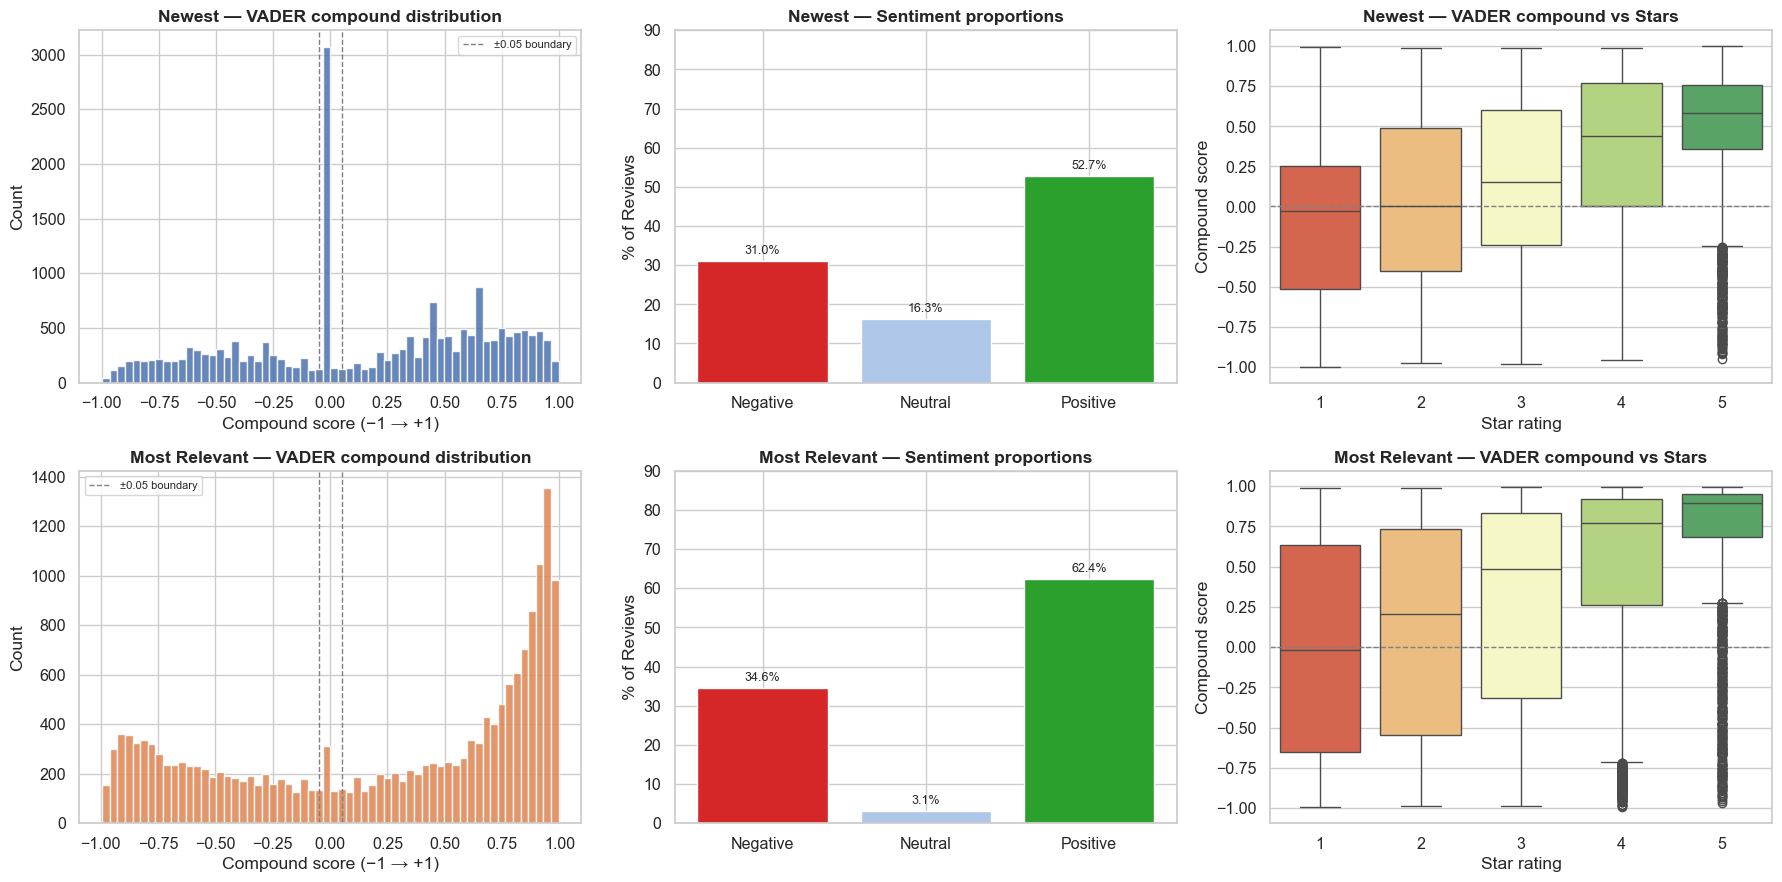

In [7]:
SENT_COLORS = {"Negative": "#d62728", "Neutral": "#aec7e8", "Positive": "#2ca02c"}

fig, axes = plt.subplots(2, 3, figsize=(18, 9))

for ds_i, (label, df_) in enumerate(datasets):
    color = PALETTE[label]

    # Compound score distribution
    axes[ds_i, 0].hist(df_["vader_compound"], bins=60, color=color, edgecolor="white", alpha=0.85)
    axes[ds_i, 0].axvline(-0.05, color="grey", linestyle="--", linewidth=1, label="±0.05 boundary")
    axes[ds_i, 0].axvline( 0.05, color="grey", linestyle="--", linewidth=1)
    axes[ds_i, 0].set_title(f"{label} — VADER compound distribution", fontweight="bold")
    axes[ds_i, 0].set_xlabel("Compound score (−1 → +1)"); axes[ds_i, 0].set_ylabel("Count")
    axes[ds_i, 0].legend(fontsize=8)

    # Sentiment label proportions
    props = (df_["sentiment_label"]
             .value_counts(normalize=True)
             .reindex(["Negative", "Neutral", "Positive"])
             .fillna(0))
    bars = axes[ds_i, 1].bar(props.index, props.values * 100,
                              color=[SENT_COLORS[k] for k in props.index], edgecolor="white")
    axes[ds_i, 1].bar_label(bars, fmt="%.1f%%", padding=3, fontsize=9)
    axes[ds_i, 1].set_title(f"{label} — Sentiment proportions", fontweight="bold")
    axes[ds_i, 1].set_ylabel("% of Reviews"); axes[ds_i, 1].set_ylim(0, 90)

    # Compound score vs star rating
    sns.boxplot(data=df_, x="stars", y="vader_compound", ax=axes[ds_i, 2],
                palette="RdYlGn", order=[1, 2, 3, 4, 5])
    axes[ds_i, 2].axhline(0, color="grey", linestyle="--", linewidth=1)
    axes[ds_i, 2].set_title(f"{label} — VADER compound vs Stars", fontweight="bold")
    axes[ds_i, 2].set_xlabel("Star rating"); axes[ds_i, 2].set_ylabel("Compound score")

plt.tight_layout()
plt.savefig("vader_analysis.png", dpi=150, bbox_inches="tight")
plt.show()


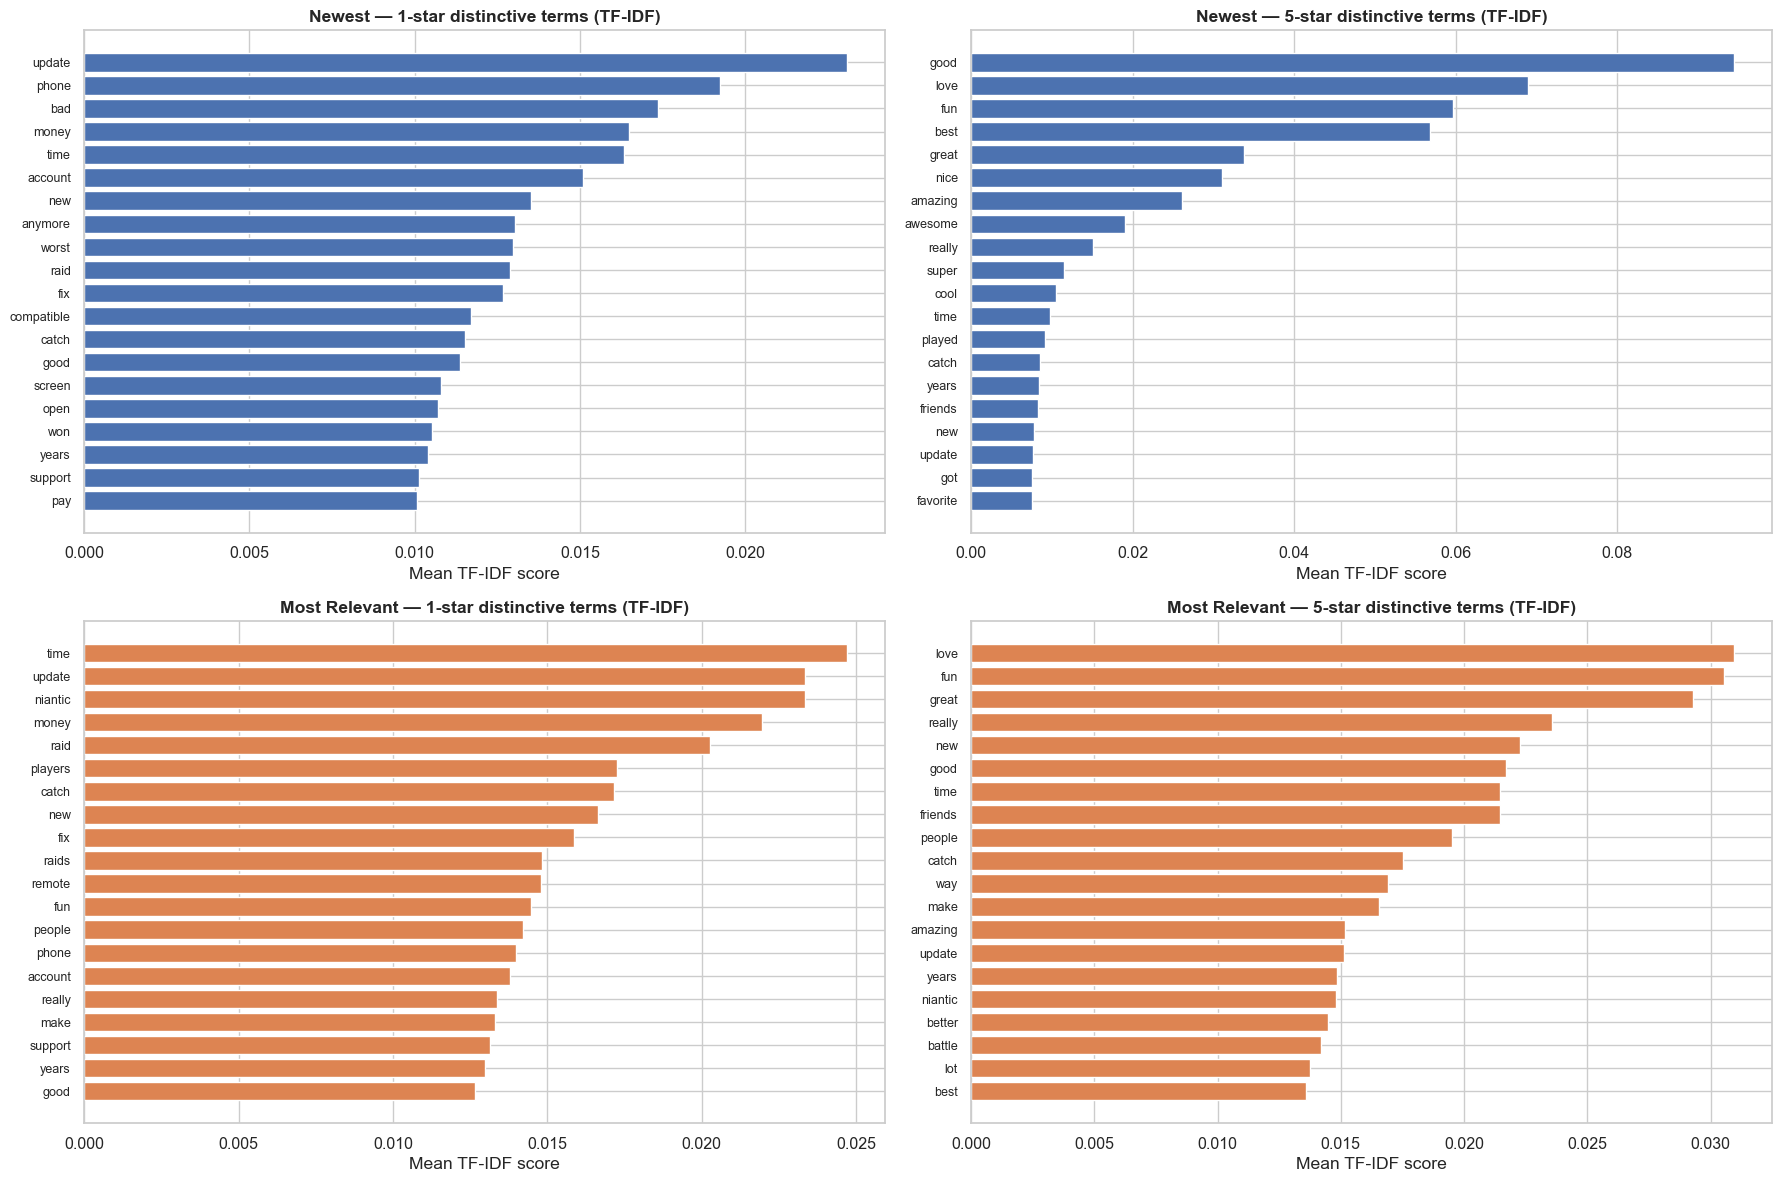

In [8]:
# TF-IDF: top distinguishing terms per star tier (1-star vs 5-star) per dataset
EXTRA_STOPS = set(ENGLISH_STOP_WORDS) | {
    "game", "pokemon", "go", "pokémon", "app", "play", "playing",
    "games", "like", "just", "don", "ve", "it", "s", "re", "t",
    "im", "ive", "don't", "it's", "i've", "i'm", "cant", "can't",
}

def top_tfidf(texts, n=20):
    vec = TfidfVectorizer(
        max_features=3000, ngram_range=(1, 2),
        stop_words=list(EXTRA_STOPS), min_df=5,
    )
    X = vec.fit_transform(texts)
    mean_scores = X.mean(axis=0).A1
    terms = vec.get_feature_names_out()
    return pd.Series(mean_scores, index=terms).nlargest(n)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
tiers = {"1-star": 1, "5-star": 5}

for ds_i, (label, df_) in enumerate(datasets):
    for tier_i, (tier_name, star_val) in enumerate(tiers.items()):
        texts = df_.loc[df_["stars"] == star_val, "review_text"].fillna("").tolist()
        top = top_tfidf(texts, n=20)
        ax = axes[ds_i, tier_i]
        ax.barh(top.index[::-1], top.values[::-1],
                color=PALETTE[label], edgecolor="white")
        ax.set_title(f"{label} — {tier_name} distinctive terms (TF-IDF)", fontweight="bold")
        ax.set_xlabel("Mean TF-IDF score")
        ax.tick_params(axis="y", labelsize=9)

plt.tight_layout()
plt.savefig("tfidf_terms.png", dpi=150, bbox_inches="tight")
plt.show()


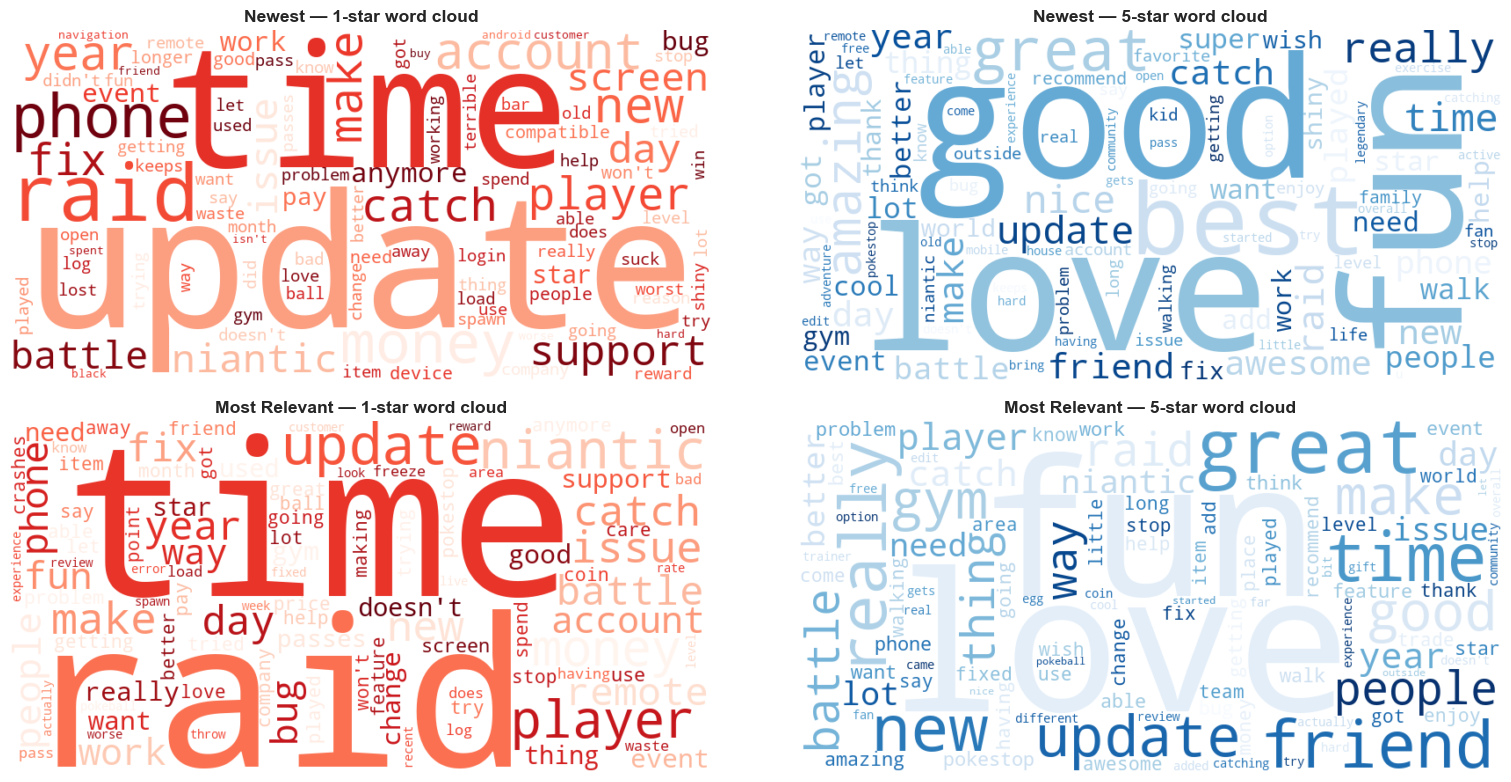

In [9]:
# Word clouds: 1-star and 5-star reviews per dataset
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

for ds_i, (label, df_) in enumerate(datasets):
    for tier_i, (tier_name, star_val, wc_color) in enumerate([
        ("1-star", 1, "Reds"),
        ("5-star", 5, "Blues"),
    ]):
        texts = " ".join(
            df_.loc[df_["stars"] == star_val, "review_text"].fillna("").str.lower().tolist()
        )
        wc = WordCloud(
            width=800, height=400,
            background_color="white",
            stopwords=EXTRA_STOPS,
            colormap=wc_color,
            max_words=100,
            collocations=False,
        ).generate(texts)
        axes[ds_i, tier_i].imshow(wc, interpolation="bilinear")
        axes[ds_i, tier_i].axis("off")
        axes[ds_i, tier_i].set_title(f"{label} — {tier_name} word cloud", fontweight="bold")

plt.tight_layout()
plt.savefig("word_clouds.png", dpi=150, bbox_inches="tight")
plt.show()


## 14 · Quantitative: Theoretical Construct Variables & Regression

### Construct operationalisation

Each construct is measured as the **term-frequency ratio**: count of matching words / total word count in that review (a normalised proportion in [0, 1]).

| Construct | Keywords |
|---|---|
| **Gamification** | reward, quest, raid, level, levels, points, badge, badge, challenge, achievement, daily, streak, bonus |
| **Flow / immersion** | immersive, addictive, engaging, fun, hooked, captivating, absorbed, exciting, thrilling, enjoyable |
| **User engagement** | active, motivation, motivated, motivated, returning, daily, routine, habit, community |
| **Exploration** | explore, walk, outside, visit, adventure, discover, outdoor, hiking, travel, neighborhood |
| **Frustration / tech** | bug, crash, lag, freeze, freezing, glitch, error, broken, fail, slow, loading, disconnect, server |

### Regression models

1. **OLS** — `stars ~ construct_scores + log_helpful + review_length`  
   Continuous response; tells us which constructs associate with higher/lower ratings.
2. **Logistic (binary)** — `low_rating (1–2 star) ~ constructs + controls`  
   Directly models probability of a negative review.
3. Each model is run **separately per dataset** so we can compare coefficients.


In [10]:
import re as _re

CONSTRUCTS = {
    "gamification": [
        "reward", "rewards", "quest", "quests", "raid", "raids",
        "level", "levels", "points", "badge", "badges",
        "challenge", "achievement", "achievements", "streak", "bonus",
    ],
    "flow": [
        "immersive", "addictive", "engaging", "fun", "hooked",
        "captivating", "absorbed", "exciting", "thrilling", "enjoyable",
        "enjoy", "enjoyed", "enjoyment",
    ],
    "engagement": [
        "active", "motivation", "motivated", "returning", "daily",
        "routine", "habit", "community", "social", "friends",
    ],
    "exploration": [
        "explore", "exploring", "walk", "walking", "outside",
        "visit", "adventure", "discover", "outdoor", "hiking",
        "travel", "neighborhood", "neighbourhood",
    ],
    "frustration": [
        "bug", "bugs", "crash", "crashes", "crashed", "lag", "lagging",
        "freeze", "freezing", "glitch", "glitches", "error", "errors",
        "broken", "fail", "failing", "slow", "loading", "disconnect",
        "server", "servers",
    ],
}

def build_constructs(df_: pd.DataFrame) -> pd.DataFrame:
    """Add one normalised construct score column per construct."""
    tokens_series = df_["review_text"].fillna("").str.lower().str.split()
    wc = tokens_series.str.len().replace(0, np.nan)
    for name, keywords in CONSTRUCTS.items():
        kw_set = set(keywords)
        counts = tokens_series.apply(lambda toks: sum(1 for t in toks if t in kw_set))
        df_[f"c_{name}"] = counts / wc  # normalised frequency
    return df_

df_new = build_constructs(df_new)
df_rel = build_constructs(df_rel)
datasets = [("Newest", df_new), ("Most Relevant", df_rel)]

CONSTRUCT_COLS = [f"c_{k}" for k in CONSTRUCTS]
print("Construct columns added:", CONSTRUCT_COLS)
df_new[CONSTRUCT_COLS].describe().round(4)


Construct columns added: ['c_gamification', 'c_flow', 'c_engagement', 'c_exploration', 'c_frustration']


,c_gamification,c_flow,c_engagement,c_exploration,c_frustration
count,20100.0000,20100.0000,20100.0000,20100.0000,20100.0000
mean,0.0038,0.0124,0.0018,0.0021,0.0053
std,0.0157,0.0758,0.0133,0.0149,0.0267
min,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0000,0.0000,0.0000,0.0000,0.0000
50%,0.0000,0.0000,0.0000,0.0000,0.0000
75%,0.0000,0.0000,0.0000,0.0000,0.0000
max,0.5000,1.0000,0.5000,0.4000,1.0000


In [11]:
# Presence rate and mean stars per construct mention
summary_rows = []
for label, df_ in datasets:
    for col in CONSTRUCT_COLS:
        name = col.replace("c_", "")
        has = df_[col] > 0
        summary_rows.append({
            "Dataset":    label,
            "Construct":  name,
            "% reviews mentioning": has.mean() * 100,
            "Mean stars — mentions":    df_.loc[has, "stars"].mean(),
            "Mean stars — no mention":  df_.loc[~has, "stars"].mean(),
            "Δ stars (mention − none)": df_.loc[has, "stars"].mean() - df_.loc[~has, "stars"].mean(),
        })

summary_df = pd.DataFrame(summary_rows).set_index(["Dataset", "Construct"]).round(3)
display(summary_df)


% reviews mentioning  Mean stars — mentions  \
Dataset       Construct                                                   
Newest        gamification                9.9700                 2.1670   
              flow                       10.5120                 3.4810   
              engagement                  4.4230                 2.9220   
              exploration                 4.2940                 3.1770   
              frustration                 9.6870                 2.0130   
Most Relevant gamification               22.9540                 2.3770   
              flow                       20.7820                 2.9390   
              engagement                 13.2170                 2.9100   
              exploration                12.1280                 2.9980   
              frustration                23.1840                 2.3910   

                            Mean stars — no mention  Δ stars (mention − none)  
Dataset       Construct                                                        
Newest        gamification                   2.8070                   -0.6400  
              flow                           2.6570                    0.8240  
              engagement                     2.7350                    0.1870  
              exploration                    2.7240                    0.4530  
              frustration                    2.8220                   -0.8080  
Most Relevant gamification                   2.5920                   -0.2150  
              flow                           2.4390                    0.5010  
              engagement                     2.4870                    0.4230  
              exploration                    2.4800                    0.5180  
              frustration                    2.5890                   -0.1970

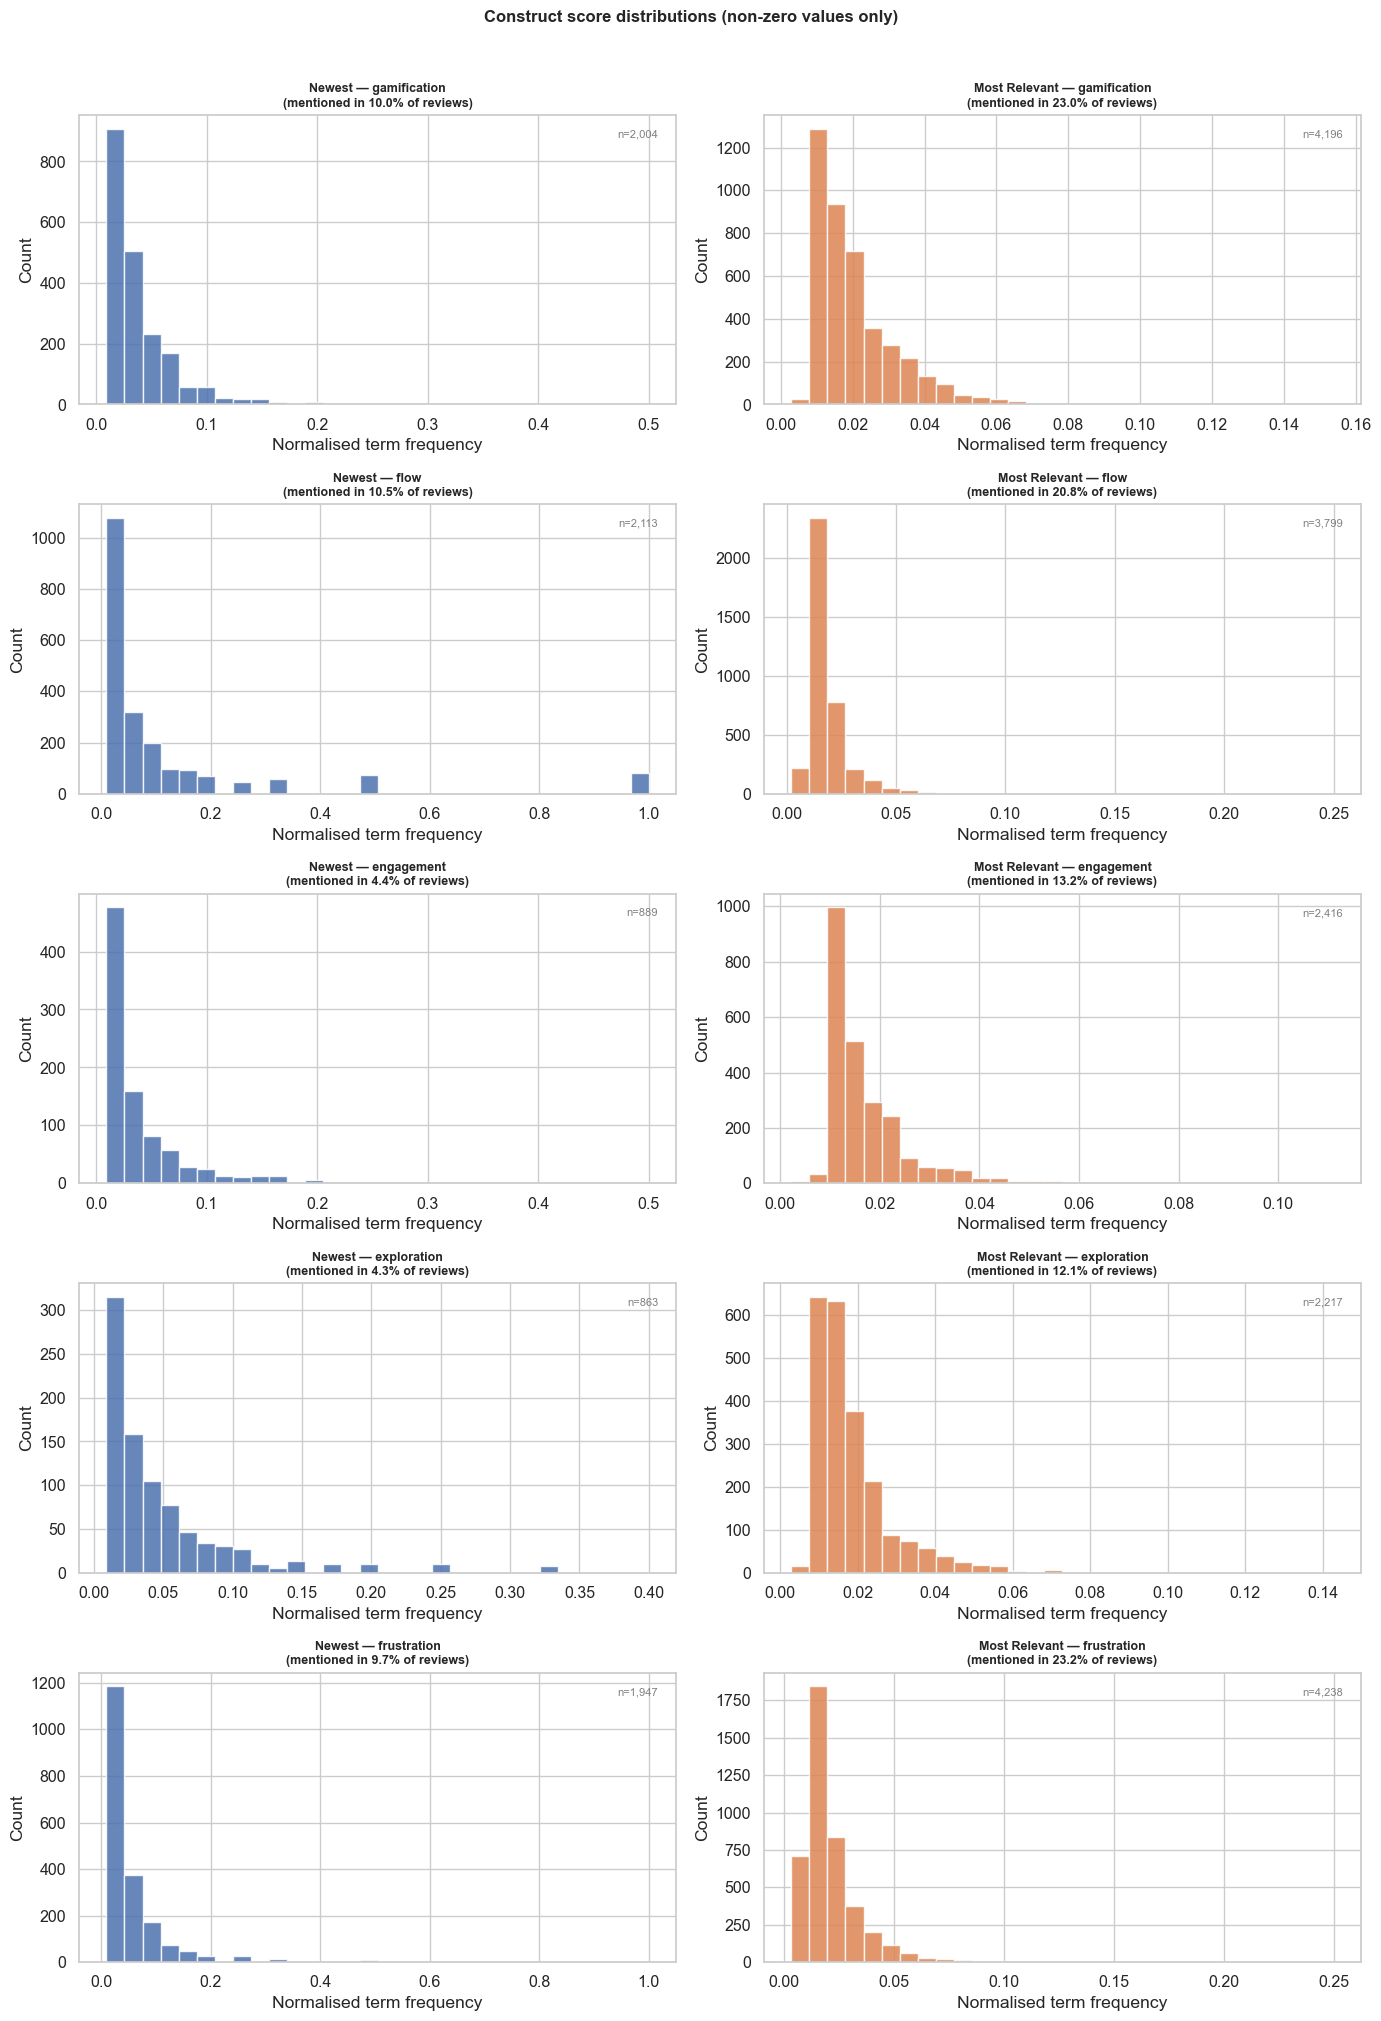

In [12]:
# Distribution of construct scores
fig, axes = plt.subplots(len(CONSTRUCT_COLS), 2, figsize=(14, 4 * len(CONSTRUCT_COLS)))

for row_i, col in enumerate(CONSTRUCT_COLS):
    name = col.replace("c_", "")
    for ds_i, (label, df_) in enumerate(datasets):
        ax = axes[row_i, ds_i]
        nonzero = df_.loc[df_[col] > 0, col]
        pct = (df_[col] > 0).mean() * 100
        ax.hist(nonzero, bins=30, color=PALETTE[label], edgecolor="white", alpha=0.85)
        ax.set_title(f"{label} — {name}\n(mentioned in {pct:.1f}% of reviews)", fontweight="bold", fontsize=9)
        ax.set_xlabel("Normalised term frequency"); ax.set_ylabel("Count")
        ax.text(0.97, 0.95, f"n={len(nonzero):,}", transform=ax.transAxes,
                ha="right", va="top", fontsize=8, color="grey")

plt.suptitle("Construct score distributions (non-zero values only)", fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("construct_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


### 14a · OLS Regression: `stars ~ constructs + controls`


In [13]:
import statsmodels.formula.api as smf

OLS_FEATURES = CONSTRUCT_COLS + ["log_helpful", "log_review_len"]
# Sanitise column names for patsy formula (no dots, starts with letter)
def safe_col(c): return c.replace(".", "_")

ols_results = {}

for label, df_ in datasets:
    reg_df = df_[OLS_FEATURES + ["stars"]].dropna().copy()
    reg_df.columns = [safe_col(c) for c in reg_df.columns]

    predictors = " + ".join([safe_col(c) for c in OLS_FEATURES])
    formula = f"stars ~ {predictors}"
    model = smf.ols(formula, data=reg_df).fit()
    ols_results[label] = model
    print(f"\n{'='*60}\nOLS — {label}\n{'='*60}")
    print(model.summary2().tables[1].round(4).to_string())
    print(f"  R²={model.rsquared:.4f}  Adj-R²={model.rsquared_adj:.4f}  N={int(model.nobs):,}")



OLS — Newest
                 Coef.  Std.Err.        t  P>|t|  [0.025  0.975]
Intercept       4.6505    0.0438 106.1235 0.0000  4.5646  4.7364
c_gamification -2.7191    0.6994  -3.8877 0.0001 -4.0899 -1.3482
c_flow          1.9381    0.1471  13.1776 0.0000  1.6499  2.2264
c_engagement    7.4225    0.8241   9.0069 0.0000  5.8072  9.0378
c_exploration   6.1666    0.7318   8.4267 0.0000  4.7322  7.6010
c_frustration  -4.8919    0.4084 -11.9779 0.0000 -5.6925 -4.0914
log_helpful    -0.4197    0.0124 -33.9502 0.0000 -0.4439 -0.3955
log_review_len -0.3729    0.0102 -36.6133 0.0000 -0.3928 -0.3529
  R²=0.2069  Adj-R²=0.2067  N=20,100

OLS — Most Relevant
                 Coef.  Std.Err.       t  P>|t|   [0.025  0.975]
Intercept       3.2387    0.1635 19.8085 0.0000   2.9182  3.5591
c_gamification -8.7133    0.9970 -8.7395 0.0000 -10.6675 -6.7591
c_flow         21.9353    1.1532 19.0216 0.0000  19.6750 24.1956
c_engagement   23.6351    1.6280 14.5176 0.0000  20.4440 26.8262
c_exploration  19.

### 14b · Logistic Regression: `low_rating (1–2★) ~ constructs + controls`


In [14]:
logit_results = {}

for label, df_ in datasets:
    reg_df = df_[OLS_FEATURES + ["stars"]].dropna().copy()
    reg_df["low_rating"] = (reg_df["stars"] <= 2).astype(int)
    reg_df.columns = [safe_col(c) for c in reg_df.columns]

    predictors = " + ".join([safe_col(c) for c in OLS_FEATURES])
    formula = f"low_rating ~ {predictors}"
    model = smf.logit(formula, data=reg_df).fit(disp=False)
    logit_results[label] = model

    # Odds ratios
    or_table = pd.DataFrame({
        "Coef":      model.params,
        "OR":        np.exp(model.params),
        "OR 95% lo": np.exp(model.conf_int()[0]),
        "OR 95% hi": np.exp(model.conf_int()[1]),
        "p-value":   model.pvalues,
        "sig":       ["***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "" for p in model.pvalues]
    })
    print(f"\n{'='*60}\nLogit — {label}   (Pseudo-R²={model.prsquared:.4f}  N={int(model.nobs):,})\n{'='*60}")
    print(or_table.round(4).to_string())



Logit — Newest   (Pseudo-R²=0.1426  N=20,100)
                   Coef       OR  OR 95% lo  OR 95% hi  p-value  sig
Intercept       -1.8401   0.1588     0.1403     0.1798   0.0000  ***
c_gamification   2.0830   8.0281     1.2119    53.1834   0.0308    *
c_flow         -17.1073   0.0000     0.0000     0.0000   0.0000  ***
c_engagement   -13.9890   0.0000     0.0000     0.0000   0.0000  ***
c_exploration   -7.4998   0.0006     0.0000     0.0080   0.0000  ***
c_frustration    5.1452 171.6029    47.5441   619.3737   0.0000  ***
log_helpful      0.7218   2.0581     1.9645     2.1561   0.0000  ***
log_review_len   0.3573   1.4294     1.3887     1.4713   0.0000  ***

Logit — Most Relevant   (Pseudo-R²=0.0332  N=18,280)
                   Coef         OR  OR 95% lo    OR 95% hi  p-value  sig
Intercept       -0.5912     0.5537     0.3493       0.8776   0.0119    *
c_gamification  11.2000 73128.7787  4113.5384 1300053.0931   0.0000  ***
c_flow         -31.2490     0.0000     0.0000       0.0000 

### 14c · Coefficient Plots (side-by-side comparison of both datasets)


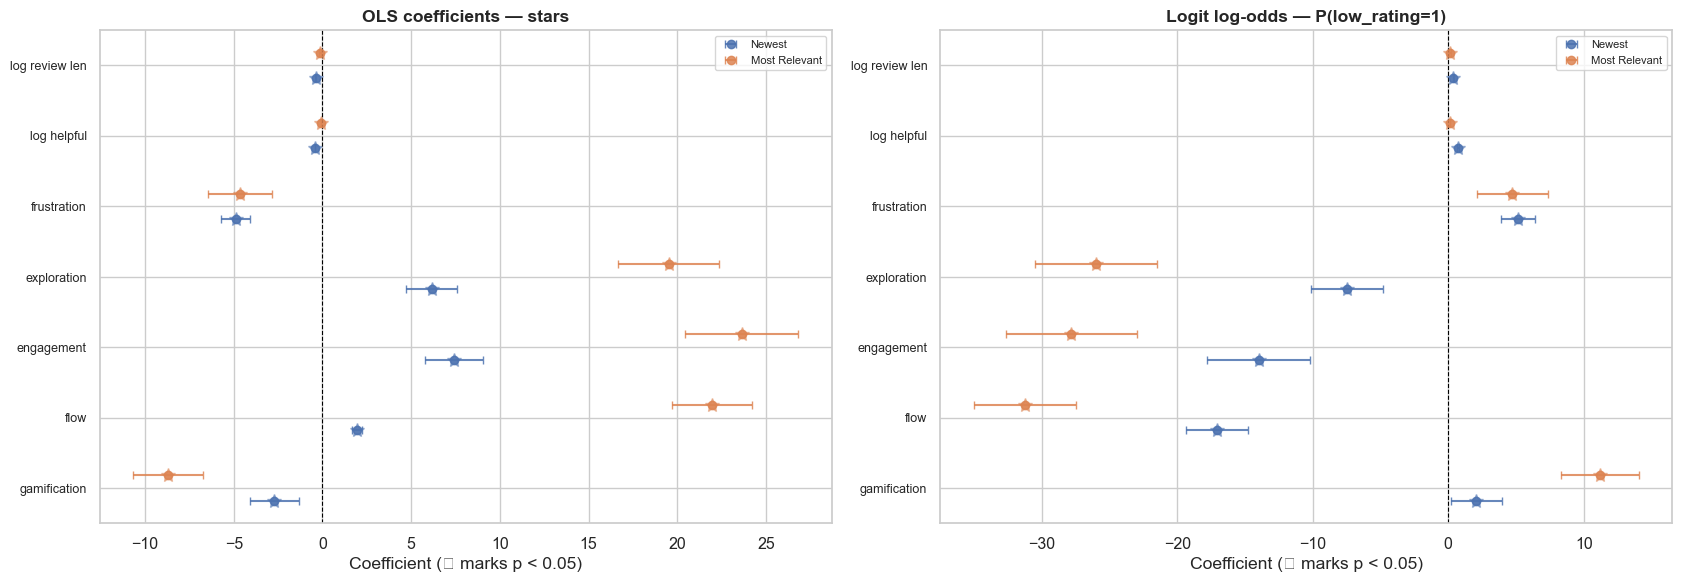

In [15]:
def coef_plot(results_dict: dict, model_type: str, title: str, ax):
    """Plot coefficients with 95% CIs side-by-side for two models."""
    n_datasets = len(results_dict)
    all_params = list(list(results_dict.values())[0].params.index)
    # Drop intercept for readability
    params = [p for p in all_params if p != "Intercept"]

    offsets = np.linspace(-0.18, 0.18, n_datasets)
    for i, (label, model) in enumerate(results_dict.items()):
        ci = model.conf_int()
        coefs = model.params[params]
        lo    = ci.loc[params, 0]
        hi    = ci.loc[params, 1]
        pvals = model.pvalues[params]

        y_pos = np.arange(len(params)) + offsets[i]
        color = PALETTE[label]

        ax.errorbar(
            coefs, y_pos,
            xerr=[coefs - lo, hi - coefs],
            fmt="o", color=color, label=label,
            capsize=3, linewidth=1.5, markersize=6,
            alpha=0.85,
        )
        # Mark significant points
        for j, (c, y, p) in enumerate(zip(coefs, y_pos, pvals)):
            if p < 0.05:
                ax.plot(c, y, marker="*", color=color, markersize=10, alpha=0.5)

    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_yticks(range(len(params)))
    ax.set_yticklabels([p.replace("c_", "").replace("_", " ") for p in params], fontsize=9)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Coefficient (★ marks p < 0.05)")
    ax.legend(fontsize=8)


fig, axes = plt.subplots(1, 2, figsize=(17, 6))

coef_plot(ols_results,   "OLS",   "OLS coefficients — stars",            axes[0])
coef_plot(logit_results, "Logit", "Logit log-odds — P(low_rating=1)",    axes[1])

plt.tight_layout()
plt.savefig("coefficient_plots.png", dpi=150, bbox_inches="tight")
plt.show()


### 14d · Regression VIF check on construct predictors


In [17]:
from statsmodels.tools.tools import add_constant

def compute_vif(df_: pd.DataFrame, cols: list) -> pd.DataFrame:
    X = df_[cols].dropna()
    X_const = add_constant(X)
    return pd.DataFrame({
        "Feature": cols,
        "VIF": [variance_inflation_factor(X_const.values, i + 1) for i in range(len(cols))],
    }).sort_values("VIF", ascending=False)

REG_COLS = [safe_col(c) for c in OLS_FEATURES]

for label, df_ in datasets:
    reg_df = df_[OLS_FEATURES].dropna().copy()
    reg_df.columns = REG_COLS
    vif = compute_vif(reg_df, REG_COLS)
    vif.columns = ["Feature", f"VIF ({label})"]
    print(f"\nVIF — regression predictors ({label})")
    print(vif.set_index("Feature").round(3).to_string())



VIF — regression predictors (Newest)
                VIF (Newest)
Feature                     
log_review_len        1.2650
log_helpful           1.2050
c_flow                1.0450
c_gamification        1.0150
c_engagement          1.0020
c_exploration         1.0020
c_frustration         1.0020

VIF — regression predictors (Most Relevant)
                VIF (Most Relevant)
Feature                            
log_review_len               1.0950
log_helpful                  1.0620
c_frustration                1.0280
c_flow                       1.0160
c_exploration                1.0080
c_engagement                 1.0070
c_gamification               1.0050


### 14e · Construct correlation with VADER sentiment


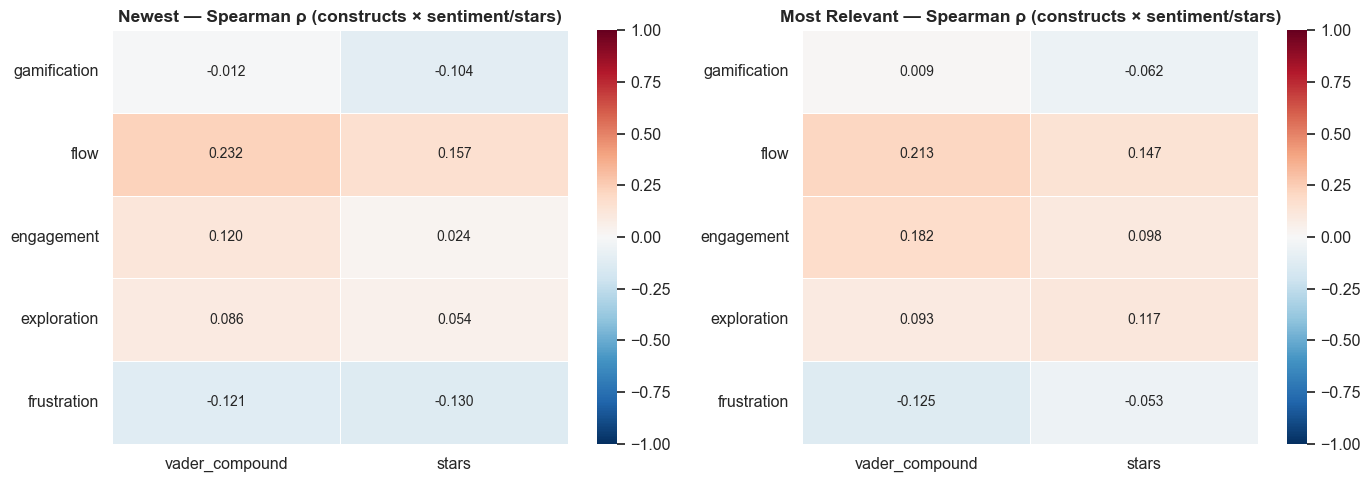

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (label, df_) in zip(axes, datasets):
    heat_cols = CONSTRUCT_COLS + ["vader_compound", "stars"]
    corr = df_[heat_cols].corr(method="spearman")
    # Show only construct × (sentiment + stars) slice
    sub = corr.loc[CONSTRUCT_COLS, ["vader_compound", "stars"]]
    sns.heatmap(
        sub, annot=True, fmt=".3f", cmap="RdBu_r", center=0,
        vmin=-1, vmax=1, ax=ax, linewidths=0.5,
        annot_kws={"size": 10},
    )
    ax.set_title(f"{label} — Spearman ρ (constructs × sentiment/stars)", fontweight="bold")
    ax.set_yticklabels([c.replace("c_", "") for c in CONSTRUCT_COLS], rotation=0)

plt.tight_layout()
plt.savefig("construct_sentiment_corr.png", dpi=150, bbox_inches="tight")
plt.show()


## 15 · Framework Testing: Path Analysis & Mediation

The theoretical framework proposes a sequential causal chain:

> **Gamification Mechanics → Flow Experience → User Engagement → Exploration Behaviour → Tourism Outcomes**

### Mapping to our data

| Framework construct | Variable | Notes |
|---|---|---|
| Gamification Mechanics | `c_gamification` | keyword TF ratio ✓ |
| Flow Experience | `c_flow` | keyword TF ratio ✓ |
| User Engagement | `c_engagement` | keyword TF ratio ✓ |
| Exploration Behaviour | `c_exploration` | keyword TF ratio ✓ |
| Tourism Outcomes — *satisfaction* | `stars` | star rating (proxy) ✓ |
| Tourism Outcomes — *length of stay* | — | not measurable from reviews ✗ |
| Tourism Outcomes — *repeat visits* | — | not measurable from reviews ✗ |

> Note: `c_frustration` is **not** part of this theoretical framework — it was included in Section 14 as an additional control variable.

### Tests performed

1. **Construct intercorrelations** — do the 4 framework constructs co-vary in the expected direction?
2. **Path regressions** — does each arrow in the chain hold after controlling for all prior constructs? Reports standardised β coefficients.
3. **Mediation analysis** — does gamification's effect on satisfaction operate *indirectly* through flow, engagement, and exploration (bootstrapped indirect effects)?

> ⚠️ **Limitations**: (a) construct scores are keyword-frequency proxies, not validated psychometric scales; (b) mediation from cross-sectional observational data cannot establish causality; (c) only *satisfaction* (stars) is observable as a tourism outcome.


Note: you may need to restart the kernel to use updated packages.
pingouin 0.6.1 imported OK


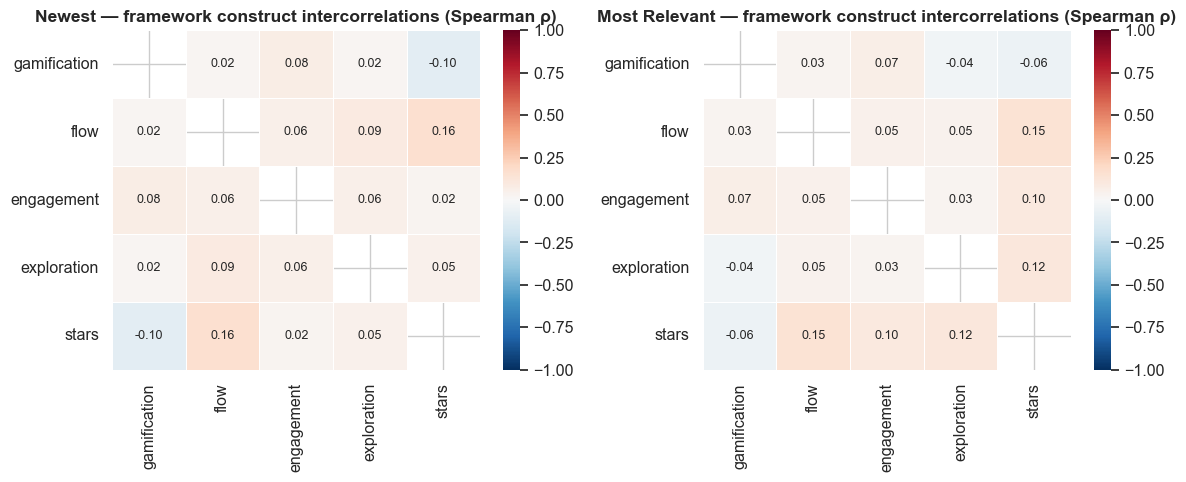

In [19]:
%pip install -q pingouin
import pingouin as pg
print(f"pingouin {pg.__version__} imported OK")

# Framework chain (excludes frustration — not in the theoretical model)
CHAIN = ["c_gamification", "c_flow", "c_engagement", "c_exploration", "stars"]
CHAIN_LABELS = ["gamification", "flow", "engagement", "exploration", "stars"]

# --- Construct intercorrelation heatmap ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (label, df_) in zip(axes, datasets):
    corr = df_[CHAIN].corr(method="spearman")
    mask = np.eye(len(CHAIN), dtype=bool)          # hide diagonal (self-corr = 1)
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
                vmin=-1, vmax=1, ax=ax, linewidths=0.5, mask=mask,
                annot_kws={"size": 9},
                xticklabels=CHAIN_LABELS,
                yticklabels=CHAIN_LABELS)
    ax.set_title(f"{label} — framework construct intercorrelations (Spearman ρ)", fontweight="bold")

plt.tight_layout()
plt.savefig("construct_chain_corr.png", dpi=150, bbox_inches="tight")
plt.show()


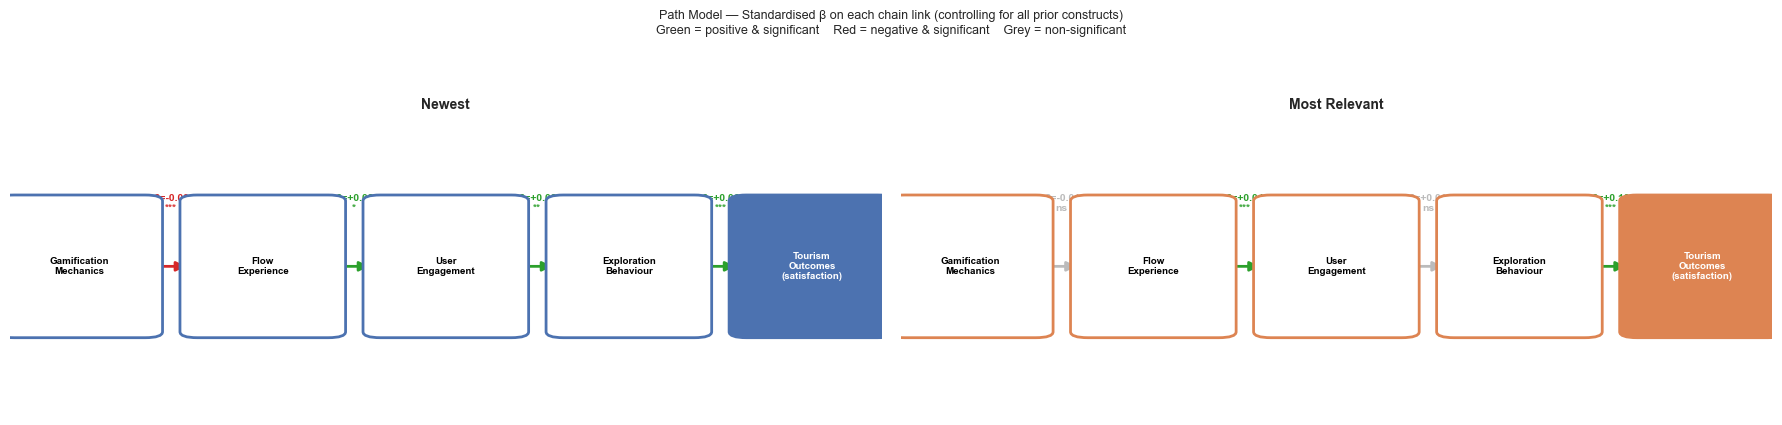


Path coefficients — standardised β (controlling for prior constructs):



,Newest β,Most Relevant β
Path,,
gamification → flow,-0.029 ***,-0.006 ns
flow → engagement,+0.017 *,+0.043 ***
engagement → exploration,+0.023 **,+0.005 ns
exploration → stars,+0.059 ***,+0.100 ***


In [21]:
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
from matplotlib.patches import FancyBboxPatch

CHAIN_LABELS_DIAG = [
    "Gamification\nMechanics",
    "Flow\nExperience",
    "User\nEngagement",
    "Exploration\nBehaviour",
    "Tourism\nOutcomes\n(satisfaction)",
]

all_paths = {}   # store (beta, pval) per dataset per link for the summary table

fig, axes = plt.subplots(1, 2, figsize=(18, 4))

for ax, (label, df_) in zip(axes, datasets):
    work   = df_[CHAIN].dropna().copy()
    z      = pd.DataFrame(StandardScaler().fit_transform(work), columns=CHAIN)
    col_ds = PALETTE[label]
    all_paths[label] = {}

    N  = len(CHAIN)
    xs = np.linspace(0.08, 0.92, N)
    y  = 0.50
    hw = 0.075   # node half-width
    hh = 0.22    # node half-height

    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")
    ax.set_title(f"{label}", fontweight="bold", fontsize=10)

    # --- arrows (drawn before nodes so nodes sit on top) ---
    for i in range(N - 1):
        preds = CHAIN[:i + 1]
        m_ = smf.ols(f"{CHAIN[i+1]} ~ " + " + ".join(preds), data=z).fit()
        beta = m_.params[CHAIN[i]]
        pval = m_.pvalues[CHAIN[i]]
        all_paths[label][(i, i + 1)] = (beta, pval)

        arrow_col = ("#2ca02c" if (beta > 0 and pval < 0.05) else
                     "#d62728" if (beta < 0 and pval < 0.05) else "#bbbbbb")
        sig_str = ("***" if pval < 0.001 else "**" if pval < 0.01 else
                   "*"   if pval < 0.05  else "ns")

        ax.annotate("",
            xy=(xs[i + 1] - hw - 0.01, y),
            xytext=(xs[i] + hw + 0.01, y),
            arrowprops=dict(arrowstyle="-|>", color=arrow_col, lw=2.0, mutation_scale=14))

        mid = (xs[i] + xs[i + 1]) / 2
        ax.text(mid, y + 0.18, f"β={beta:+.2f}\n{sig_str}",
                ha="center", va="bottom", fontsize=7.5, color=arrow_col, fontweight="bold")

    # --- nodes ---
    for i, (x, lbl) in enumerate(zip(xs, CHAIN_LABELS_DIAG)):
        fc = col_ds if i == N - 1 else "white"
        tc = "white" if i == N - 1 else "black"
        rect = FancyBboxPatch((x - hw, y - hh), 2 * hw, 2 * hh,
                              boxstyle="round,pad=0.02",
                              facecolor=fc, edgecolor=col_ds,
                              linewidth=2, zorder=3)
        ax.add_patch(rect)
        ax.text(x, y, lbl, ha="center", va="center",
                fontsize=7, fontweight="bold", zorder=4, color=tc)

plt.suptitle(
    "Path Model — Standardised β on each chain link (controlling for all prior constructs)\n"
    "Green = positive & significant    Red = negative & significant    Grey = non-significant",
    fontsize=9, y=1.06)
plt.tight_layout()
plt.savefig("path_diagram.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Tabular summary ---
print("\nPath coefficients — standardised β (controlling for prior constructs):\n")
tbl_rows = []
for i in range(len(CHAIN) - 1):
    row = {"Path": f"{CHAIN_LABELS[i]} → {CHAIN_LABELS[i+1]}"}
    for label, _ in datasets:
        beta, pval = all_paths[label][(i, i + 1)]
        sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "ns"
        row[f"{label} β"] = f"{beta:+.3f} {sig}"
    tbl_rows.append(row)
display(pd.DataFrame(tbl_rows).set_index("Path"))


In [22]:
# Mediation analysis: c_gamification → [mediator] → stars
# Reports total effect (c), direct effect (c'), indirect effect (ab = a*b),
# and whether the indirect path is significant (bootstrapped 95% CI).

for label, df_ in datasets:
    work = df_[CHAIN].dropna().copy()
    print(f"\n{'='*65}\nMediation — {label}\n"
          f"X = c_gamification   Y = stars (satisfaction)\n{'='*65}\n")

    frames = []
    for med_col, med_name in [
        ("c_flow",        "Flow"),
        ("c_engagement",  "Engagement"),
        ("c_exploration", "Exploration"),
    ]:
        res = pg.mediation_analysis(
            data=work, x="c_gamification", m=med_col, y="stars",
            n_boot=2000, seed=42,
        )
        res.insert(0, "Mediator", med_name)
        frames.append(res)

    combined = pd.concat(frames, ignore_index=True)
    display(combined.set_index(["Mediator", "path"]).round(4))



Mediation — Newest
X = c_gamification   Y = stars (satisfaction)



coef     se   pval   CI2.5  CI97.5  sig
Mediator    path                                                        
Flow        c_flow ~ X        -0.1411 0.0340 0.0000 -0.2078 -0.0745  Yes
            Y ~ c_flow         3.6598 0.1594 0.0000  3.3473  3.9723  Yes
            Total             -7.6390 0.7774 0.0000 -9.1628 -6.1151  Yes
            Direct            -7.1285 0.7680 0.0000 -8.6338 -5.6232  Yes
            Indirect          -0.5104 0.0424 0.0000 -0.5924 -0.4292  Yes
Engagement  c_engagement ~ X   0.0117 0.0059 0.0489  0.0001  0.0234  Yes
            Y ~ c_engagement   7.7308 0.9225 0.0000  5.9225  9.5390  Yes
            Total             -7.6390 0.7774 0.0000 -9.1628 -6.1151  Yes
            Direct            -7.7310 0.7761 0.0000 -9.2523 -6.2098  Yes
            Indirect           0.0920 0.0579 0.0600  0.0002  0.2245   No
Exploration c_exploration ~ X -0.0184 0.0067 0.0061 -0.0315 -0.0053  Yes
            Y ~ c_exploration  7.2135 0.8191 0.0000  5.6080  8.8191  Yes
            Total             -7.6390 0.7774 0.0000 -9.1628 -6.1151  Yes
            Direct            -7.5092 0.7762 0.0000 -9.0305 -5.9879  Yes
            Indirect          -0.1298 0.0233 0.0000 -0.1767 -0.0857  Yes


Mediation — Most Relevant
X = c_gamification   Y = stars (satisfaction)



coef     se   pval    CI2.5  CI97.5  sig
Mediator    path                                                         
Flow        c_flow ~ X        -0.0049 0.0064 0.4491  -0.0175  0.0077   No
            Y ~ c_flow        24.0531 1.1641 0.0000  21.7714 26.3349  Yes
            Total             -8.9103 1.0216 0.0000 -10.9126 -6.9079  Yes
            Direct            -8.7935 1.0099 0.0000 -10.7730 -6.8140  Yes
            Indirect          -0.1168 0.1432 0.3980  -0.3652  0.1992   No
Engagement  c_engagement ~ X   0.0209 0.0045 0.0000   0.0121  0.0298  Yes
            Y ~ c_engagement  24.8396 1.6594 0.0000  21.5870 28.0923  Yes
            Total             -8.9103 1.0216 0.0000 -10.9126 -6.9079  Yes
            Direct            -9.4417 1.0157 0.0000 -11.4325 -7.4508  Yes
            Indirect           0.5314 0.1225 0.0000   0.3058  0.7914  Yes
Exploration c_exploration ~ X -0.0286 0.0051 0.0000  -0.0386 -0.0187  Yes
            Y ~ c_exploration 21.8478 1.4804 0.0000  18.9460 24.7495  Yes
            Total             -8.9103 1.0216 0.0000 -10.9126 -6.9079  Yes
            Direct            -8.2995 1.0167 0.0000 -10.2923 -6.3067  Yes
            Indirect          -0.6108 0.0994 0.0000  -0.8159 -0.4245  Yes